# Weather Impact on Waiting Times - Data Exploration

This notebook explores the relationship between weather variables (X) and amusement park waiting times (Y).

**Objective:** Understand how weather conditions affect ride waiting times to build a predictive model.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

%matplotlib inline

## 1. Load the Data

In [15]:
# Load weather data
weather_df = pd.read_csv('../final_data/weather_data.csv')
print(f"Weather data shape: {weather_df.shape}")
print(f"Weather data date range: {weather_df['dt_iso'].min()} to {weather_df['dt_iso'].max()}")
weather_df.head()

Weather data shape: (207264, 28)
Weather data date range: 1999-01-01 00:00:00 +0000 UTC to 2022-08-23 23:00:00 +0000 UTC


,dt,dt_iso,timezone,city_name,lat,lon,temp,visibility,dew_point,feels_like,...,wind_gust,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,915148800,1999-01-01 00:00:00 +0000 UTC,3600,Custom location,48.873492,2.295104,8.33,NaN,3.39,5.28,...,NaN,NaN,NaN,NaN,NaN,8,800,Clear,sky is clear,01n
1,915152400,1999-01-01 01:00:00 +0000 UTC,3600,Custom location,48.873492,2.295104,8.08,NaN,3.54,5.18,...,NaN,NaN,NaN,NaN,NaN,6,800,Clear,sky is clear,01n
2,915156000,1999-01-01 02:00:00 +0000 UTC,3600,Custom location,48.873492,2.295104,8.08,NaN,4.11,5.38,...,NaN,NaN,NaN,NaN,NaN,14,801,Clouds,few clouds,02n
3,915159600,1999-01-01 03:00:00 +0000 UTC,3600,Custom location,48.873492,2.295104,7.31,NaN,3.73,4.42,...,NaN,NaN,NaN,NaN,NaN,39,802,Clouds,scattered clouds,03n
4,915163200,1999-01-01 04:00:00 +0000 UTC,3600,Custom location,48.873492,2.295104,6.91,NaN,3.53,4.00,...,NaN,NaN,NaN,NaN,NaN,52,803,Clouds,broken clouds,04n


In [16]:
# Load waiting times data
waiting_df = pd.read_csv('../final_data/waiting_times.csv')
print(f"Waiting times shape: {waiting_df.shape}")
print(f"Waiting times date range: {waiting_df['WORK_DATE'].min()} to {waiting_df['WORK_DATE'].max()}")
waiting_df.head()

Waiting times shape: (3509324, 14)
Waiting times date range: 2018-01-01 to 2022-08-18


,WORK_DATE,DEB_TIME,DEB_TIME_HOUR,FIN_TIME,ENTITY_DESCRIPTION_SHORT,WAIT_TIME_MAX,NB_UNITS,GUEST_CARRIED,CAPACITY,ADJUST_CAPACITY,OPEN_TIME,UP_TIME,DOWNTIME,NB_MAX_UNIT
0,2018-01-01,2018-01-01 21:00:00.000,21,2018-01-01 21:15:00.000,Roller Coaster,0,2.0,0.0,0.000,0.00,0,0,0,2.0
1,2018-01-01,2018-01-01 19:30:00.000,19,2018-01-01 19:45:00.000,Bumper Cars,5,18.0,148.0,254.749,254.75,15,15,0,18.0
2,2018-01-01,2018-01-01 22:30:00.000,22,2018-01-01 22:45:00.000,Rapids Ride,0,1.0,0.0,0.000,0.00,0,0,0,2.0
3,2018-01-01,2018-01-01 12:45:00.000,12,2018-01-01 13:00:00.000,Crazy Dance,5,1.0,46.0,250.001,250.00,15,15,0,1.0
4,2018-01-01,2018-01-01 17:00:00.000,17,2018-01-01 17:15:00.000,Skyway,5,15.0,92.0,211.500,198.25,15,15,0,16.0


## 2. Data Preprocessing

In [17]:
# Parse datetime columns
weather_df['dt_iso'] = pd.to_datetime(weather_df['dt_iso'].str.replace(' \+0000 UTC', '', regex=True))
weather_df['date'] = weather_df['dt_iso'].dt.date
weather_df['hour'] = weather_df['dt_iso'].dt.hour

print("Weather data columns:", weather_df.columns.tolist())
print(f"\nWeather date range after parsing: {weather_df['dt_iso'].min()} to {weather_df['dt_iso'].max()}")

Weather data columns: ['dt', 'dt_iso', 'timezone', 'city_name', 'lat', 'lon', 'temp', 'visibility', 'dew_point', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'sea_level', 'grnd_level', 'humidity', 'wind_speed', 'wind_deg', 'wind_gust', 'rain_1h', 'rain_3h', 'snow_1h', 'snow_3h', 'clouds_all', 'weather_id', 'weather_main', 'weather_description', 'weather_icon', 'date', 'hour']

Weather date range after parsing: 1999-01-01 00:00:00 to 2022-08-23 23:00:00


In [44]:
waiting_df.head()

,WORK_DATE,DEB_TIME,DEB_TIME_HOUR,FIN_TIME,ENTITY_DESCRIPTION_SHORT,WAIT_TIME_MAX,NB_UNITS,GUEST_CARRIED,CAPACITY,ADJUST_CAPACITY,OPEN_TIME,UP_TIME,DOWNTIME,NB_MAX_UNIT,date,hour
0,2018-01-01,2018-01-01 21:00:00,21,2018-01-01 21:15:00.000,Roller Coaster,0,2.0,0.0,0.000,0.00,0,0,0,2.0,2018-01-01,21
1,2018-01-01,2018-01-01 19:30:00,19,2018-01-01 19:45:00.000,Bumper Cars,5,18.0,148.0,254.749,254.75,15,15,0,18.0,2018-01-01,19
2,2018-01-01,2018-01-01 22:30:00,22,2018-01-01 22:45:00.000,Rapids Ride,0,1.0,0.0,0.000,0.00,0,0,0,2.0,2018-01-01,22
3,2018-01-01,2018-01-01 12:45:00,12,2018-01-01 13:00:00.000,Crazy Dance,5,1.0,46.0,250.001,250.00,15,15,0,1.0,2018-01-01,12
4,2018-01-01,2018-01-01 17:00:00,17,2018-01-01 17:15:00.000,Skyway,5,15.0,92.0,211.500,198.25,15,15,0,16.0,2018-01-01,17


In [18]:
# Parse waiting times datetime
waiting_df['WORK_DATE'] = pd.to_datetime(waiting_df['WORK_DATE'])
waiting_df['DEB_TIME'] = pd.to_datetime(waiting_df['DEB_TIME'])
waiting_df['date'] = waiting_df['WORK_DATE'].dt.date
waiting_df['hour'] = waiting_df['DEB_TIME_HOUR']

print("Waiting times columns:", waiting_df.columns.tolist())
print(f"\nWaiting times date range: {waiting_df['WORK_DATE'].min()} to {waiting_df['WORK_DATE'].max()}")

Waiting times columns: ['WORK_DATE', 'DEB_TIME', 'DEB_TIME_HOUR', 'FIN_TIME', 'ENTITY_DESCRIPTION_SHORT', 'WAIT_TIME_MAX', 'NB_UNITS', 'GUEST_CARRIED', 'CAPACITY', 'ADJUST_CAPACITY', 'OPEN_TIME', 'UP_TIME', 'DOWNTIME', 'NB_MAX_UNIT', 'date', 'hour']

Waiting times date range: 2018-01-01 00:00:00 to 2022-08-18 00:00:00


In [19]:
# Filter weather data to match waiting times period (2018 onwards)
weather_df = weather_df[weather_df['dt_iso'] >= '2018-01-01']
print(f"Weather data shape after filtering: {weather_df.shape}")
print(f"Weather date range after filtering: {weather_df['dt_iso'].min()} to {weather_df['dt_iso'].max()}")

Weather data shape after filtering: (40704, 30)
Weather date range after filtering: 2018-01-01 00:00:00 to 2022-08-23 23:00:00


## 3. Aggregate Waiting Times by Date and Hour

In [20]:
# Aggregate waiting times by date and hour
# We'll compute mean, max, and std of WAIT_TIME_MAX across all rides
waiting_agg = waiting_df.groupby(['date', 'hour']).agg({
    'WAIT_TIME_MAX': ['mean', 'max', 'std', 'count'],
    'GUEST_CARRIED': 'sum',
    'NB_UNITS': 'sum'
}).reset_index()

# Flatten column names
waiting_agg.columns = ['date', 'hour', 'wait_time_mean', 'wait_time_max', 'wait_time_std', 
                        'n_observations', 'total_guests', 'total_units']

print(f"Aggregated waiting times shape: {waiting_agg.shape}")
waiting_agg.head()

Aggregated waiting times shape: (23674, 8)


,date,hour,wait_time_mean,wait_time_max,wait_time_std,n_observations,total_guests,total_units
0,2018-01-01,9,5.540541,60,10.170906,148,9075.9998,2286.4667
1,2018-01-01,10,13.851351,65,15.573991,148,19056.0004,2396.9334
2,2018-01-01,11,20.371622,150,24.571783,148,18134.0000,2427.5999
3,2018-01-01,12,22.466216,120,27.339492,148,18649.4998,2603.9334
4,2018-01-01,13,20.608108,120,24.010382,148,20086.5003,2624.6000


In [21]:
# Also aggregate by date only for daily analysis
waiting_daily = waiting_df.groupby('date').agg({
    'WAIT_TIME_MAX': ['mean', 'max', 'std'],
    'GUEST_CARRIED': 'sum'
}).reset_index()

waiting_daily.columns = ['date', 'wait_time_mean', 'wait_time_max', 'wait_time_std', 'total_guests']
print(f"Daily aggregated waiting times shape: {waiting_daily.shape}")
waiting_daily.head()

Daily aggregated waiting times shape: (1691, 5)


,date,wait_time_mean,wait_time_max,wait_time_std,total_guests
0,2018-01-01,14.348456,150,19.117674,212634.8340
1,2018-01-02,22.915058,120,23.674346,266828.6609
2,2018-01-03,23.846525,120,27.341070,235157.1333
3,2018-01-04,21.795367,120,23.995727,261887.1636
4,2018-01-05,25.622587,120,25.708661,270942.4730


## 4. Aggregate Weather by Date and Hour

In [22]:
# Select relevant weather features for analysis
weather_features = ['temp', 'feels_like', 'humidity', 'wind_speed', 'pressure', 
                    'clouds_all', 'rain_1h', 'snow_1h', 'visibility', 'dew_point']

# Check missing values in weather data
print("Missing values in weather features:")
print(weather_df[weather_features].isnull().sum())

Missing values in weather features:
temp              0
feels_like        0
humidity          0
wind_speed        0
pressure          0
clouds_all        0
rain_1h       35042
snow_1h       40484
visibility    40704
dew_point         0
dtype: int64


In [23]:
# Fill missing values with 0 for rain and snow (assuming no rain/snow if missing)
weather_df['rain_1h'] = weather_df['rain_1h'].fillna(0)
weather_df['snow_1h'] = weather_df['snow_1h'].fillna(0)
weather_df['visibility'] = weather_df['visibility'].fillna(weather_df['visibility'].median())

# Aggregate weather by date
weather_daily = weather_df.groupby('date').agg({
    'temp': ['mean', 'min', 'max'],
    'feels_like': 'mean',
    'humidity': 'mean',
    'wind_speed': ['mean', 'max'],
    'pressure': 'mean',
    'clouds_all': 'mean',
    'rain_1h': 'sum',  # Total daily rainfall
    'snow_1h': 'sum',  # Total daily snowfall
    'visibility': 'mean',
    'weather_main': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'  # Most common weather
}).reset_index()

# Flatten column names
weather_daily.columns = ['date', 'temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
                         'humidity_mean', 'wind_speed_mean', 'wind_speed_max', 'pressure_mean',
                         'clouds_mean', 'rain_total', 'snow_total', 'visibility_mean', 'weather_main']

print(f"Daily weather shape: {weather_daily.shape}")
weather_daily.head()

Daily weather shape: (1696, 14)


/Users/alessandro_iva/opt/anaconda3/envs/newenv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,date,temp_mean,temp_min,temp_max,feels_like_mean,humidity_mean,wind_speed_mean,wind_speed_max,pressure_mean,clouds_mean,rain_total,snow_total,visibility_mean,weather_main
0,2018-01-01,7.401250,6.35,9.12,3.295000,82.583333,8.057083,9.89,1005.583333,65.375000,8.02,0.0,NaN,Clouds
1,2018-01-02,7.883750,5.76,12.04,5.288333,87.500000,5.613333,8.36,1013.333333,79.208333,2.34,0.0,NaN,Clouds
2,2018-01-03,9.614583,7.11,13.46,6.842083,79.958333,8.825833,12.06,1005.750000,79.500000,9.07,0.0,NaN,Rain
3,2018-01-04,10.922917,7.37,14.05,9.629167,89.916667,7.008750,9.59,1002.541667,96.041667,14.11,0.0,NaN,Rain
4,2018-01-05,8.586667,5.00,10.34,6.198333,88.000000,4.847917,7.61,1001.083333,97.791667,1.97,0.0,NaN,Clouds


## 5. Merge Weather and Waiting Times Data

In [24]:
# Merge daily data
merged_daily = pd.merge(waiting_daily, weather_daily, on='date', how='inner')
print(f"Merged daily data shape: {merged_daily.shape}")
print(f"Date range: {merged_daily['date'].min()} to {merged_daily['date'].max()}")
merged_daily.head()

Merged daily data shape: (1691, 18)
Date range: 2018-01-01 to 2022-08-18


,date,wait_time_mean,wait_time_max,wait_time_std,total_guests,temp_mean,temp_min,temp_max,feels_like_mean,humidity_mean,wind_speed_mean,wind_speed_max,pressure_mean,clouds_mean,rain_total,snow_total,visibility_mean,weather_main
0,2018-01-01,14.348456,150,19.117674,212634.8340,7.401250,6.35,9.12,3.295000,82.583333,8.057083,9.89,1005.583333,65.375000,8.02,0.0,NaN,Clouds
1,2018-01-02,22.915058,120,23.674346,266828.6609,7.883750,5.76,12.04,5.288333,87.500000,5.613333,8.36,1013.333333,79.208333,2.34,0.0,NaN,Clouds
2,2018-01-03,23.846525,120,27.341070,235157.1333,9.614583,7.11,13.46,6.842083,79.958333,8.825833,12.06,1005.750000,79.500000,9.07,0.0,NaN,Rain
3,2018-01-04,21.795367,120,23.995727,261887.1636,10.922917,7.37,14.05,9.629167,89.916667,7.008750,9.59,1002.541667,96.041667,14.11,0.0,NaN,Rain
4,2018-01-05,25.622587,120,25.708661,270942.4730,8.586667,5.00,10.34,6.198333,88.000000,4.847917,7.61,1001.083333,97.791667,1.97,0.0,NaN,Clouds


In [25]:
# Merge hourly data
weather_hourly = weather_df[['date', 'hour', 'temp', 'feels_like', 'humidity', 
                              'wind_speed', 'pressure', 'clouds_all', 'rain_1h', 
                              'snow_1h', 'weather_main']].copy()

merged_hourly = pd.merge(waiting_agg, weather_hourly, on=['date', 'hour'], how='inner')
print(f"Merged hourly data shape: {merged_hourly.shape}")
merged_hourly.head()

Merged hourly data shape: (23674, 17)


,date,hour,wait_time_mean,wait_time_max,wait_time_std,n_observations,total_guests,total_units,temp,feels_like,humidity,wind_speed,pressure,clouds_all,rain_1h,snow_1h,weather_main
0,2018-01-01,9,5.540541,60,10.170906,148,9075.9998,2286.4667,6.76,2.62,83,7.48,1007,100,0.00,0.0,Clouds
1,2018-01-01,10,13.851351,65,15.573991,148,19056.0004,2396.9334,6.77,2.68,87,7.33,1005,100,0.82,0.0,Rain
2,2018-01-01,11,20.371622,150,24.571783,148,18134.0000,2427.5999,6.35,1.46,91,9.69,1002,100,2.01,0.0,Rain
3,2018-01-01,12,22.466216,120,27.339492,148,18649.4998,2603.9334,7.77,3.28,93,9.89,998,99,0.92,0.0,Rain
4,2018-01-01,13,20.608108,120,24.010382,148,20086.5003,2624.6000,8.34,4.22,93,9.12,997,83,0.82,0.0,Rain


## 6. Exploratory Data Analysis - Waiting Times Distribution

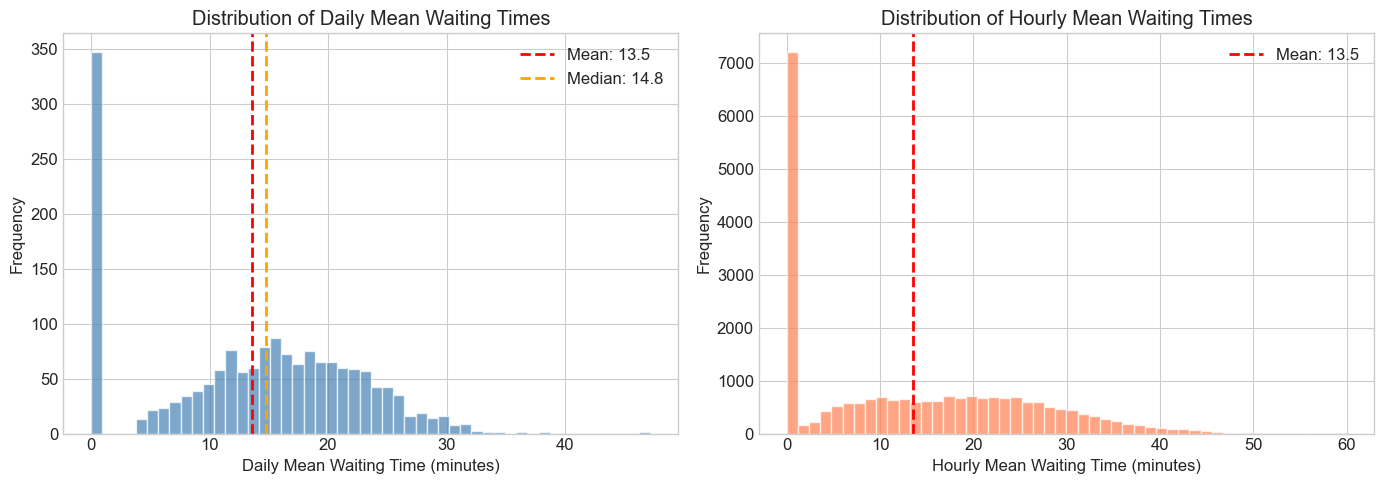

In [26]:
# Distribution of waiting times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of daily mean waiting times
axes[0].hist(merged_daily['wait_time_mean'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(merged_daily['wait_time_mean'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {merged_daily['wait_time_mean'].mean():.1f}")
axes[0].axvline(merged_daily['wait_time_mean'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {merged_daily['wait_time_mean'].median():.1f}")
axes[0].set_xlabel('Daily Mean Waiting Time (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Daily Mean Waiting Times')
axes[0].legend()

# Histogram of hourly mean waiting times
axes[1].hist(merged_hourly['wait_time_mean'], bins=50, color='coral', edgecolor='white', alpha=0.7)
axes[1].axvline(merged_hourly['wait_time_mean'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {merged_hourly['wait_time_mean'].mean():.1f}")
axes[1].set_xlabel('Hourly Mean Waiting Time (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Hourly Mean Waiting Times')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# Summary statistics for waiting times
print("Daily Mean Waiting Times Statistics:")
print(merged_daily['wait_time_mean'].describe())
print("\nHourly Mean Waiting Times Statistics:")
print(merged_hourly['wait_time_mean'].describe())

Daily Mean Waiting Times Statistics:
count    1691.000000
mean       13.539932
std         8.864675
min         0.000000
25%         7.414334
50%        14.756274
75%        20.102558
max        47.212838
Name: wait_time_mean, dtype: float64

Hourly Mean Waiting Times Statistics:
count    23674.000000
mean        13.539785
std         12.164305
min          0.000000
25%          0.000000
50%         12.286469
75%         23.074324
max         59.932432
Name: wait_time_mean, dtype: float64


## 7. Weather Variables Distribution

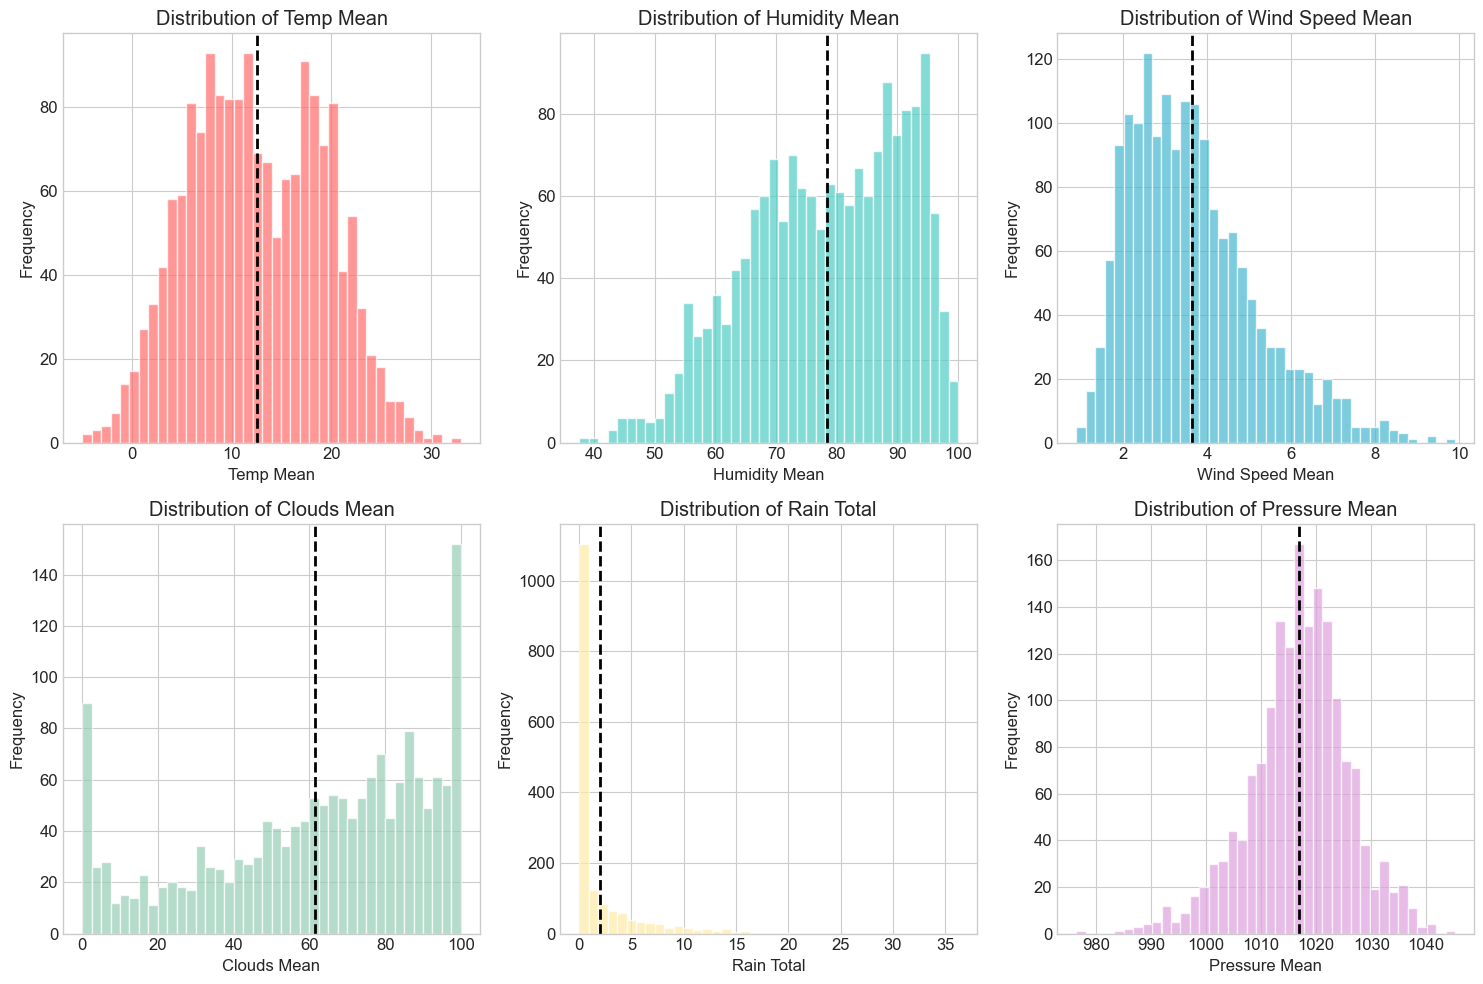

In [28]:
# Distribution of key weather variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

weather_vars = ['temp_mean', 'humidity_mean', 'wind_speed_mean', 'clouds_mean', 'rain_total', 'pressure_mean']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for ax, var, color in zip(axes.flatten(), weather_vars, colors):
    ax.hist(merged_daily[var].dropna(), bins=40, color=color, edgecolor='white', alpha=0.7)
    ax.axvline(merged_daily[var].mean(), color='black', linestyle='--', linewidth=2)
    ax.set_xlabel(var.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {var.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

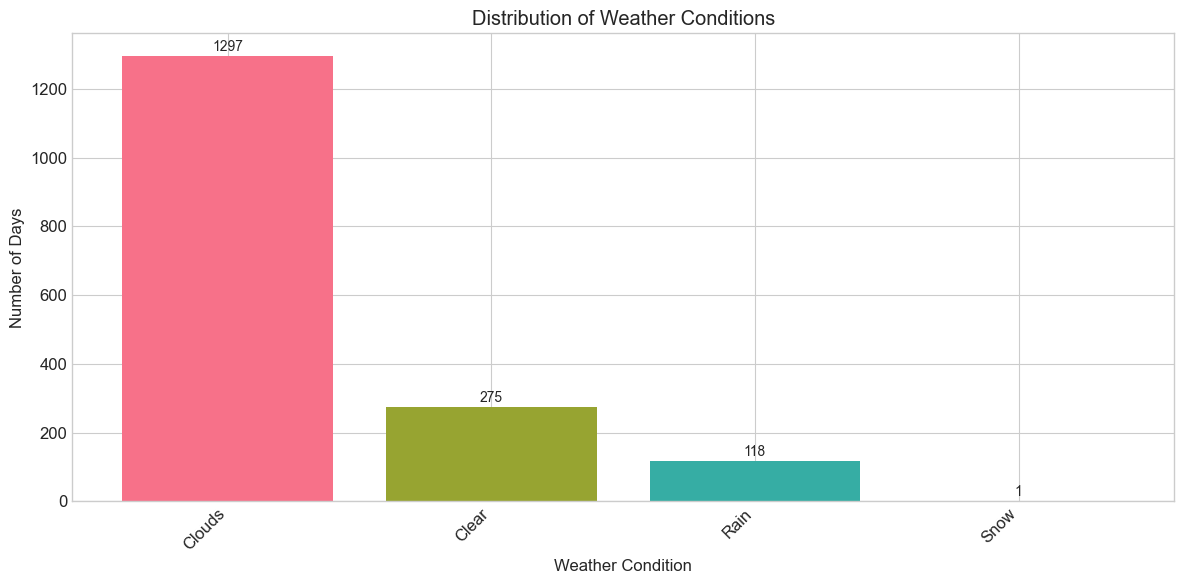

In [29]:
# Weather condition frequency
weather_counts = merged_daily['weather_main'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(weather_counts.index, weather_counts.values, color=sns.color_palette('husl', len(weather_counts)))
plt.xlabel('Weather Condition')
plt.ylabel('Number of Days')
plt.title('Distribution of Weather Conditions')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, val in zip(bars, weather_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis - Weather vs Waiting Times

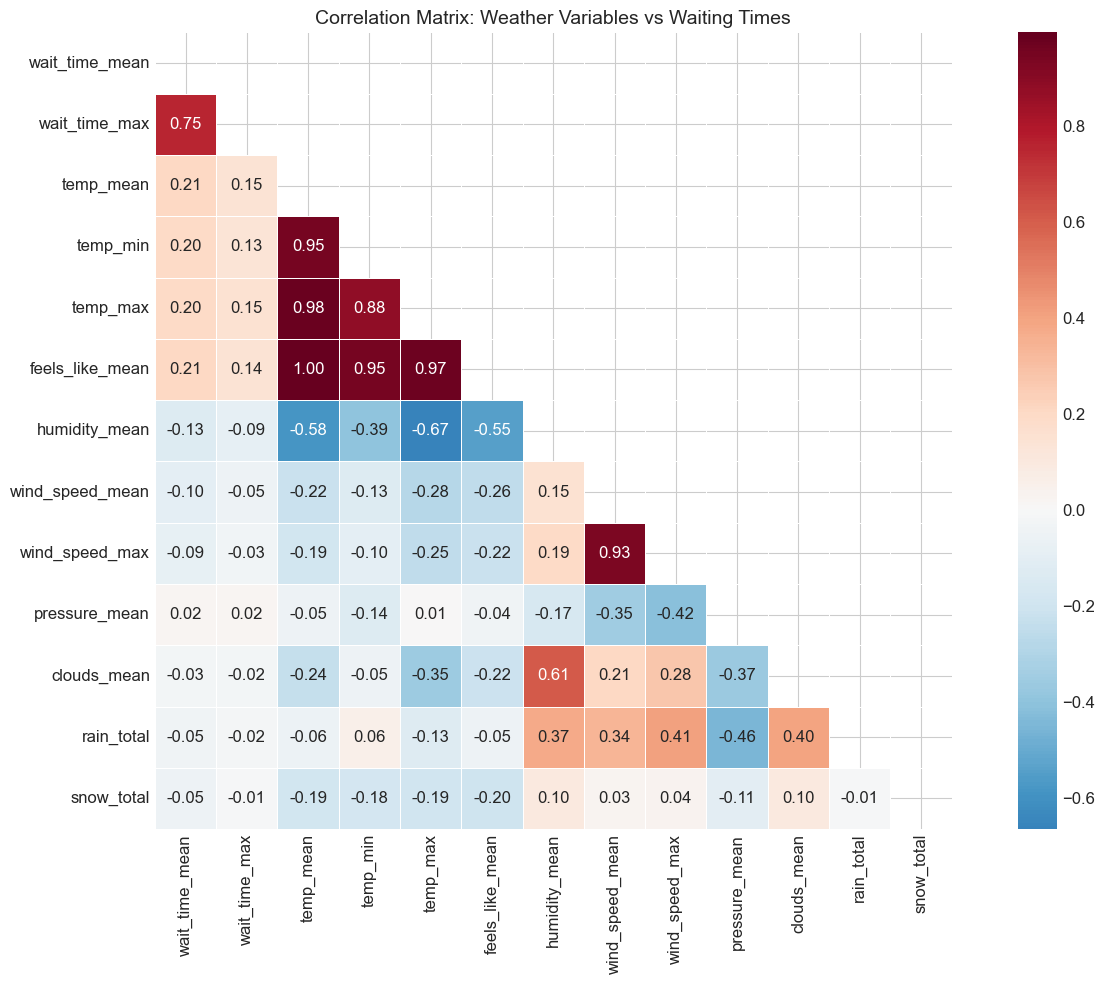

In [30]:
# Select numeric columns for correlation
numeric_cols = ['wait_time_mean', 'wait_time_max', 'temp_mean', 'temp_min', 'temp_max',
                'feels_like_mean', 'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
                'pressure_mean', 'clouds_mean', 'rain_total', 'snow_total']

# Calculate correlation matrix
correlation_matrix = merged_daily[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Weather Variables vs Waiting Times', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
# Extract correlations with waiting time
wait_correlations = correlation_matrix['wait_time_mean'].drop(['wait_time_mean', 'wait_time_max']).sort_values(key=abs, ascending=False)

print("Correlations with Mean Waiting Time (sorted by absolute value):")
print("="*50)
for var, corr in wait_correlations.items():
    direction = "↑" if corr > 0 else "↓"
    strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
    print(f"{var:25s}: {corr:+.3f} {direction} ({strength})")

Correlations with Mean Waiting Time (sorted by absolute value):
temp_mean                : +0.206 ↑ (Weak)
feels_like_mean          : +0.206 ↑ (Weak)
temp_max                 : +0.204 ↑ (Weak)
temp_min                 : +0.198 ↑ (Weak)
humidity_mean            : -0.135 ↓ (Weak)
wind_speed_mean          : -0.100 ↓ (Weak)
wind_speed_max           : -0.088 ↓ (Weak)
snow_total               : -0.050 ↓ (Weak)
rain_total               : -0.048 ↓ (Weak)
clouds_mean              : -0.026 ↓ (Weak)
pressure_mean            : +0.019 ↑ (Weak)


## 9. Scatter Plots - Weather vs Waiting Times

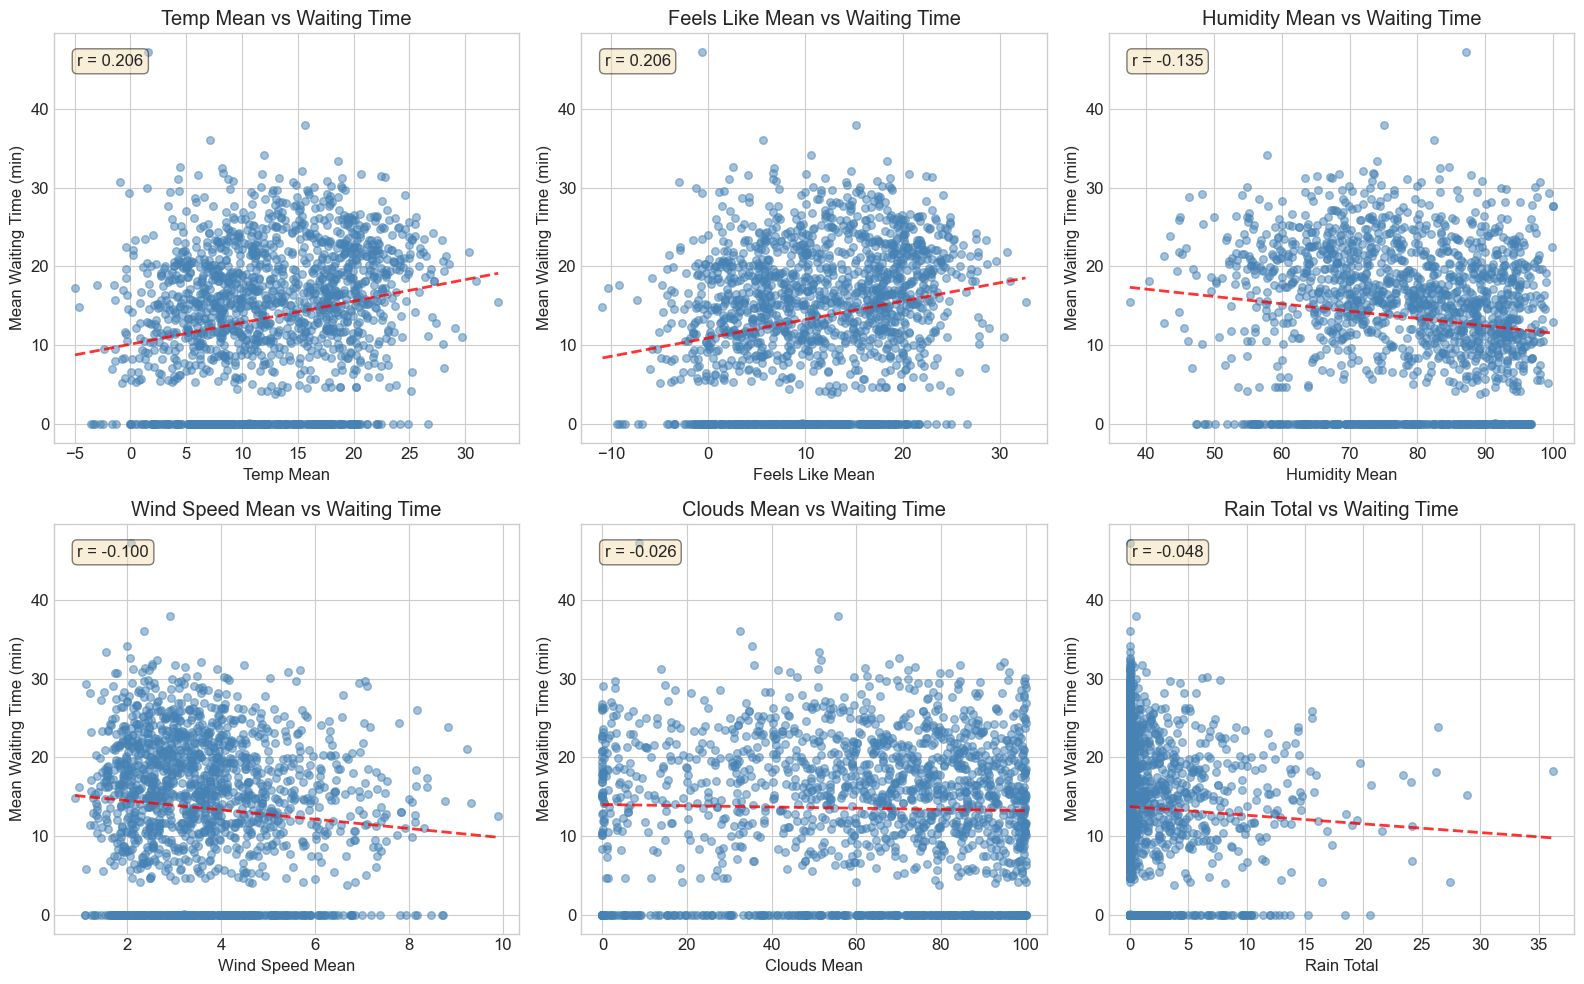

In [32]:
# Scatter plots of top correlated weather variables vs waiting times
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

top_vars = ['temp_mean', 'feels_like_mean', 'humidity_mean', 'wind_speed_mean', 'clouds_mean', 'rain_total']

for ax, var in zip(axes.flatten(), top_vars):
    # Remove outliers for better visualization
    data = merged_daily[[var, 'wait_time_mean']].dropna()
    
    ax.scatter(data[var], data['wait_time_mean'], alpha=0.5, s=30, color='steelblue')
    
    # Add regression line
    z = np.polyfit(data[var], data['wait_time_mean'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[var].min(), data[var].max(), 100)
    ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)
    
    # Calculate and display correlation
    corr = data[var].corr(data['wait_time_mean'])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(var.replace('_', ' ').title())
    ax.set_ylabel('Mean Waiting Time (min)')
    ax.set_title(f'{var.replace("_", " ").title()} vs Waiting Time')

plt.tight_layout()
plt.show()

## 10. Waiting Times by Weather Condition

/var/folders/4n/w20v1m9d2sq76wl2jmtfbq2c0000gn/T/ipykernel_42628/2467688893.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather_main', y='wait_time_mean', data=merged_daily, order=weather_order,


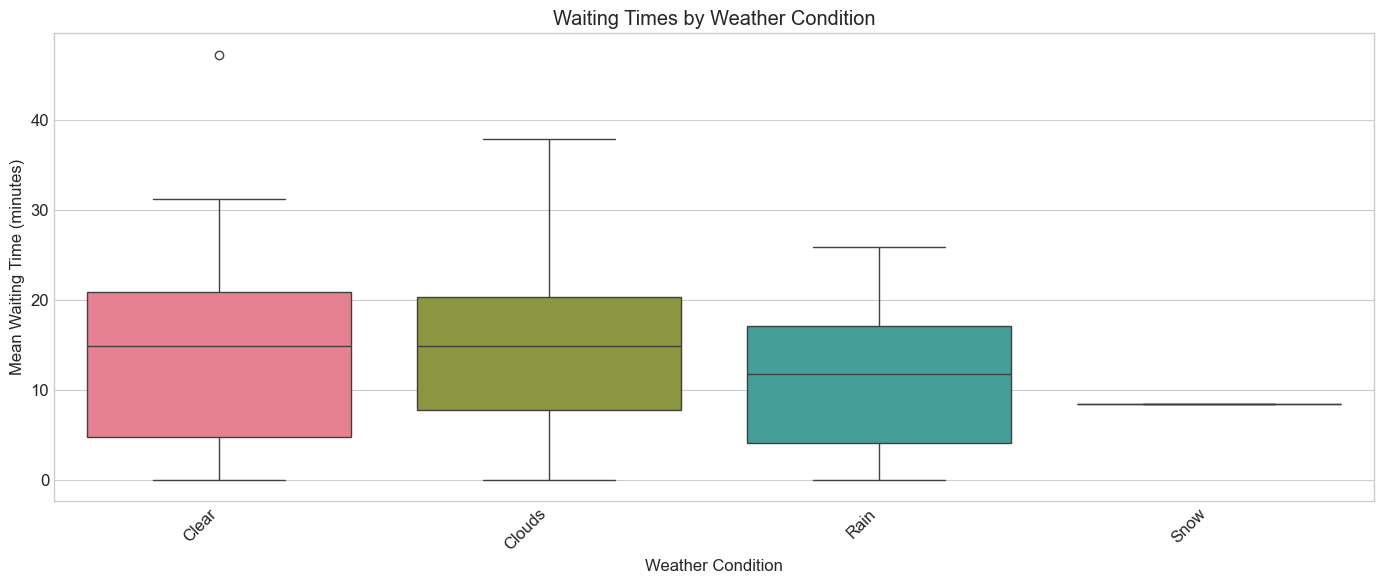

In [33]:
# Box plot of waiting times by weather condition
plt.figure(figsize=(14, 6))

# Order by median waiting time
weather_order = merged_daily.groupby('weather_main')['wait_time_mean'].median().sort_values(ascending=False).index

sns.boxplot(x='weather_main', y='wait_time_mean', data=merged_daily, order=weather_order,
            palette='husl')
plt.xlabel('Weather Condition')
plt.ylabel('Mean Waiting Time (minutes)')
plt.title('Waiting Times by Weather Condition')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
# Summary statistics by weather condition
weather_stats = merged_daily.groupby('weather_main').agg({
    'wait_time_mean': ['mean', 'median', 'std', 'count']
}).round(2)

weather_stats.columns = ['Mean', 'Median', 'Std', 'Count']
weather_stats = weather_stats.sort_values('Mean', ascending=False)

print("Waiting Time Statistics by Weather Condition:")
print("="*55)
print(weather_stats)

Waiting Time Statistics by Weather Condition:
               Mean  Median   Std  Count
weather_main                            
Clouds        13.77   14.88  8.82   1297
Clear         13.52   14.88  9.40    275
Rain          11.06   11.75  7.72    118
Snow           8.41    8.41   NaN      1


## 11. Temperature Analysis

/var/folders/4n/w20v1m9d2sq76wl2jmtfbq2c0000gn/T/ipykernel_42628/1430999289.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='temp_category', y='wait_time_mean', data=merged_daily, ax=axes[0], palette='coolwarm')


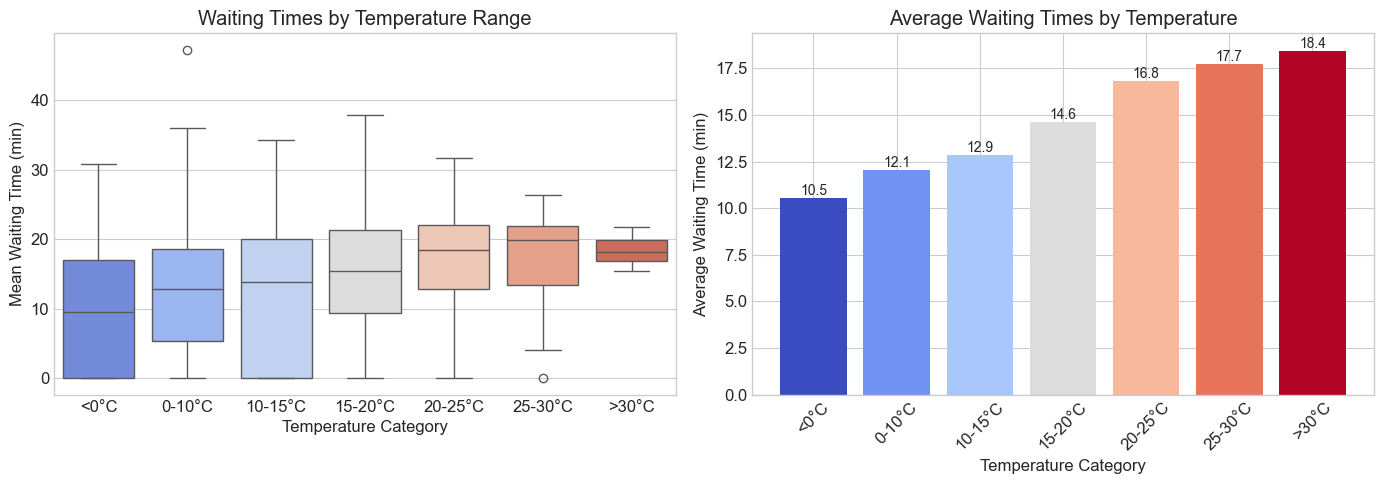

In [35]:
# Create temperature bins
temp_bins = [-10, 0, 10, 15, 20, 25, 30, 40]
temp_labels = ['<0°C', '0-10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C']
merged_daily['temp_category'] = pd.cut(merged_daily['temp_mean'], bins=temp_bins, labels=temp_labels)

# Plot waiting times by temperature category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(x='temp_category', y='wait_time_mean', data=merged_daily, ax=axes[0], palette='coolwarm')
axes[0].set_xlabel('Temperature Category')
axes[0].set_ylabel('Mean Waiting Time (min)')
axes[0].set_title('Waiting Times by Temperature Range')

# Bar plot with mean and count
temp_summary = merged_daily.groupby('temp_category').agg({
    'wait_time_mean': 'mean'
}).round(2)

bars = axes[1].bar(temp_summary.index, temp_summary['wait_time_mean'], 
                   color=plt.cm.coolwarm(np.linspace(0, 1, len(temp_summary))))
axes[1].set_xlabel('Temperature Category')
axes[1].set_ylabel('Average Waiting Time (min)')
axes[1].set_title('Average Waiting Times by Temperature')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 12. Rain and Snow Impact

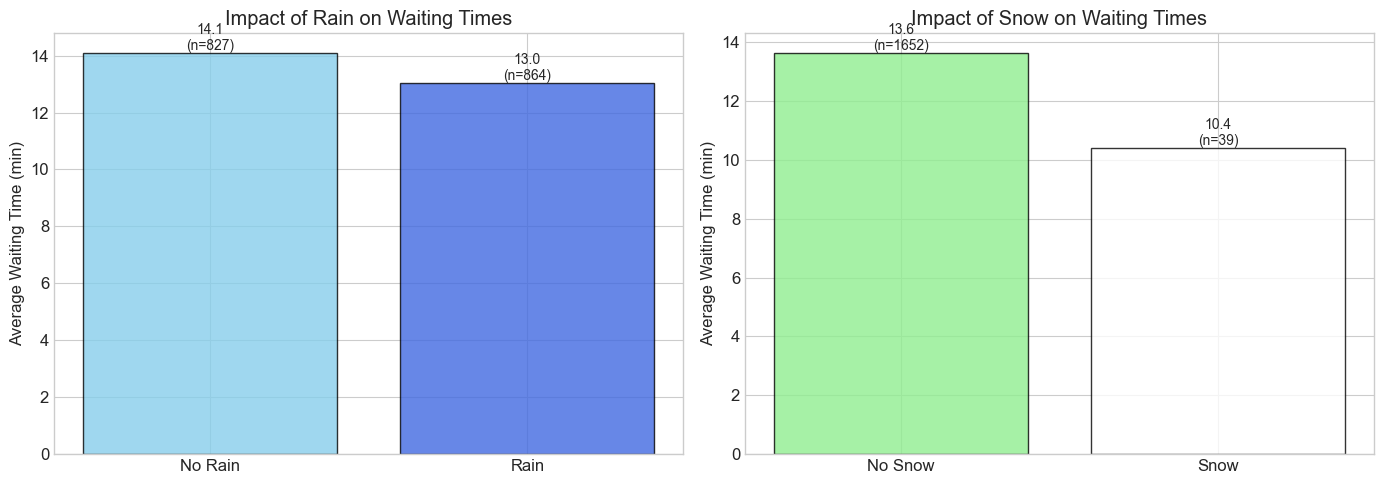


Statistical Summary:

Rain Days vs No Rain Days:
              mean     median       std  count
No Rain  14.079036  15.270270  9.286095    827
Rain     13.023915  14.208494  8.414706    864

Snow Days vs No Snow Days:
              mean     median       std  count
No Snow  13.614354  14.794884  8.878879   1652
Snow     10.387524   9.855212  7.698069     39


In [36]:
# Create rain/no rain categories
merged_daily['has_rain'] = merged_daily['rain_total'] > 0
merged_daily['has_snow'] = merged_daily['snow_total'] > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rain impact
rain_comparison = merged_daily.groupby('has_rain')['wait_time_mean'].agg(['mean', 'median', 'std', 'count'])
rain_comparison.index = ['No Rain', 'Rain']

bars1 = axes[0].bar(rain_comparison.index, rain_comparison['mean'], 
                    color=['#87CEEB', '#4169E1'], edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Average Waiting Time (min)')
axes[0].set_title('Impact of Rain on Waiting Times')

for bar, (idx, row) in zip(bars1, rain_comparison.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{row["mean"]:.1f}\n(n={int(row["count"])})', ha='center', va='bottom', fontsize=10)

# Snow impact
snow_comparison = merged_daily.groupby('has_snow')['wait_time_mean'].agg(['mean', 'median', 'std', 'count'])
snow_comparison.index = ['No Snow', 'Snow']

bars2 = axes[1].bar(snow_comparison.index, snow_comparison['mean'], 
                    color=['#90EE90', '#FFFFFF'], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Average Waiting Time (min)')
axes[1].set_title('Impact of Snow on Waiting Times')

for bar, (idx, row) in zip(bars2, snow_comparison.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{row["mean"]:.1f}\n(n={int(row["count"])})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nStatistical Summary:")
print("="*50)
print("\nRain Days vs No Rain Days:")
print(rain_comparison)
print("\nSnow Days vs No Snow Days:")
print(snow_comparison)

In [37]:
# Statistical test: t-test for rain impact
rain_waiting = merged_daily[merged_daily['has_rain']]['wait_time_mean'].dropna()
no_rain_waiting = merged_daily[~merged_daily['has_rain']]['wait_time_mean'].dropna()

t_stat, p_value = stats.ttest_ind(rain_waiting, no_rain_waiting)
print("T-test: Rain vs No Rain Days")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Statistical significance at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

T-test: Rain vs No Rain Days
T-statistic: -2.450
P-value: 0.0144
Statistical significance at α=0.05: Yes


## 13. Hourly Analysis

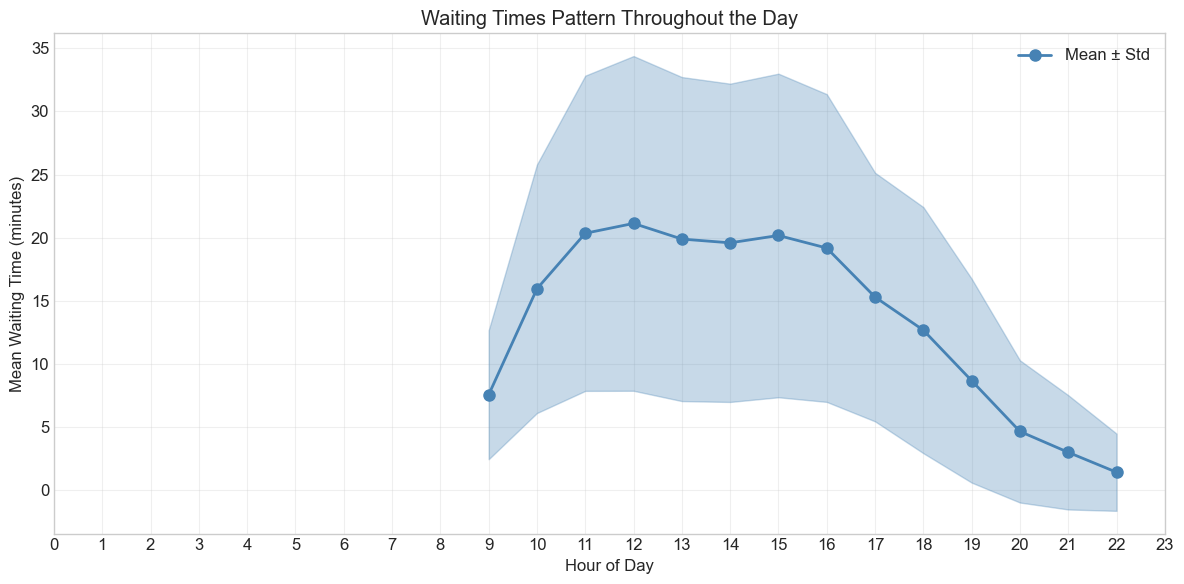

In [38]:
# Waiting times by hour of day
hourly_pattern = merged_hourly.groupby('hour')['wait_time_mean'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(12, 6))
plt.fill_between(hourly_pattern['hour'], 
                 hourly_pattern['mean'] - hourly_pattern['std'],
                 hourly_pattern['mean'] + hourly_pattern['std'], 
                 alpha=0.3, color='steelblue')
plt.plot(hourly_pattern['hour'], hourly_pattern['mean'], 'o-', color='steelblue', 
         linewidth=2, markersize=8, label='Mean ± Std')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Waiting Time (minutes)')
plt.title('Waiting Times Pattern Throughout the Day')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

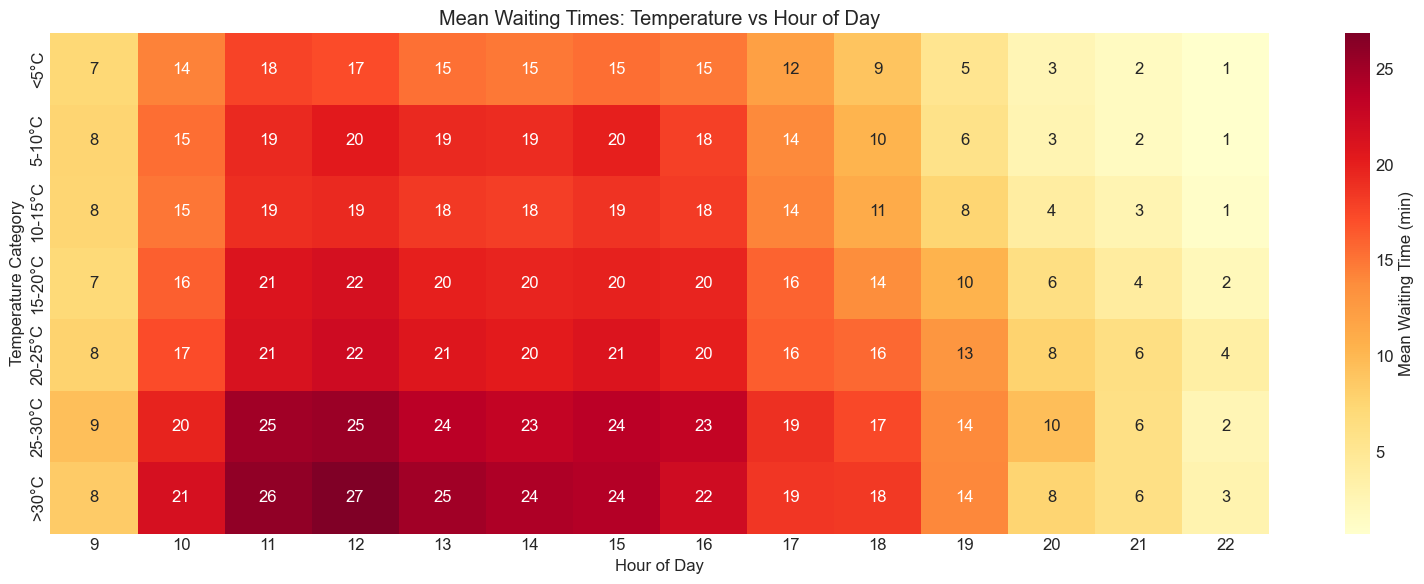

In [39]:
# Heatmap: Hour vs Temperature Effect on Waiting Times
merged_hourly['temp_category'] = pd.cut(merged_hourly['temp'], 
                                         bins=[-10, 5, 10, 15, 20, 25, 30, 40], 
                                         labels=['<5°C', '5-10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C'])

heatmap_data = merged_hourly.pivot_table(values='wait_time_mean', 
                                          index='temp_category', 
                                          columns='hour', 
                                          aggfunc='mean')

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', 
            cbar_kws={'label': 'Mean Waiting Time (min)'})
plt.xlabel('Hour of Day')
plt.ylabel('Temperature Category')
plt.title('Mean Waiting Times: Temperature vs Hour of Day')
plt.tight_layout()
plt.show()

## 14. Feature Importance Analysis

In [40]:
# Prepare data for modeling
feature_cols = ['temp_mean', 'feels_like_mean', 'humidity_mean', 'wind_speed_mean',
                'wind_speed_max', 'pressure_mean', 'clouds_mean', 'rain_total', 
                'snow_total']

# Drop rows with missing values
model_data = merged_daily[feature_cols + ['wait_time_mean']].dropna()
print(f"Data for modeling: {model_data.shape[0]} samples with {len(feature_cols)} features")

Data for modeling: 1691 samples with 9 features


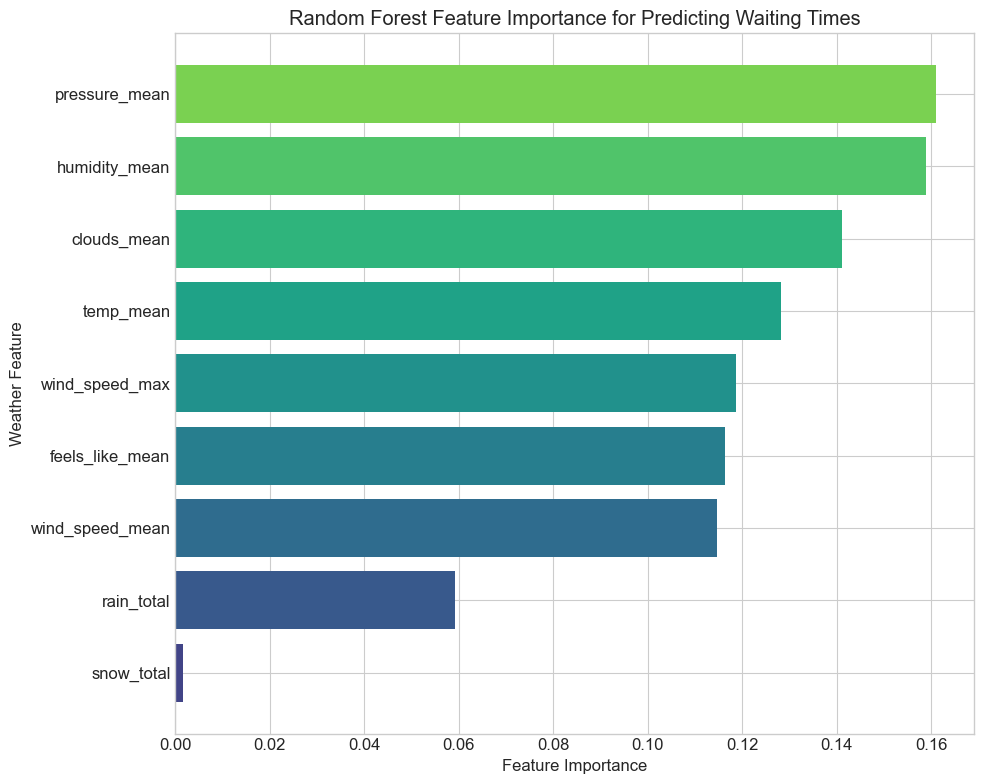


Feature Importance Ranking:
pressure_mean            : 0.1610
humidity_mean            : 0.1590
clouds_mean              : 0.1411
temp_mean                : 0.1282
wind_speed_max           : 0.1187
feels_like_mean          : 0.1163
wind_speed_mean          : 0.1147
rain_total               : 0.0592
snow_total               : 0.0016


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Prepare features and target
X = model_data[feature_cols]
y = model_data['wait_time_mean']

# Train a Random Forest to get feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_importance)))
plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
plt.xlabel('Feature Importance')
plt.ylabel('Weather Feature')
plt.title('Random Forest Feature Importance for Predicting Waiting Times')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print("="*40)
for _, row in feature_importance.sort_values('importance', ascending=False).iterrows():
    print(f"{row['feature']:25s}: {row['importance']:.4f}")

## 15. Key Findings Summary

In [42]:
# Summary of key findings
print("="*60)
print("KEY FINDINGS: WEATHER IMPACT ON WAITING TIMES")
print("="*60)

# Top 3 most important features
top_features = feature_importance.sort_values('importance', ascending=False).head(3)
print("\n1. MOST IMPORTANT WEATHER FEATURES:")
for i, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"   {i}. {row['feature'].replace('_', ' ').title()}: {row['importance']:.4f}")

# Temperature impact
temp_impact = merged_daily.groupby('temp_category')['wait_time_mean'].mean()
print("\n2. TEMPERATURE IMPACT:")
print(f"   - Lowest waiting times: {temp_impact.idxmin()} ({temp_impact.min():.1f} min)")
print(f"   - Highest waiting times: {temp_impact.idxmax()} ({temp_impact.max():.1f} min)")

# Rain impact
rain_diff = rain_comparison.loc['Rain', 'mean'] - rain_comparison.loc['No Rain', 'mean']
print("\n3. RAIN IMPACT:")
print(f"   - No rain days: {rain_comparison.loc['No Rain', 'mean']:.1f} min average")
print(f"   - Rainy days: {rain_comparison.loc['Rain', 'mean']:.1f} min average")
print(f"   - Difference: {rain_diff:+.1f} min {'(less wait on rainy days)' if rain_diff < 0 else '(more wait on rainy days)'}")

# Weather condition impact
best_weather = weather_stats['Mean'].idxmax()
worst_weather = weather_stats['Mean'].idxmin()
print("\n4. WEATHER CONDITION IMPACT:")
print(f"   - Highest waiting times: {best_weather} ({weather_stats.loc[best_weather, 'Mean']:.1f} min)")
print(f"   - Lowest waiting times: {worst_weather} ({weather_stats.loc[worst_weather, 'Mean']:.1f} min)")

# Correlation summary
print("\n5. TOP CORRELATIONS WITH WAITING TIME:")
for var, corr in wait_correlations.head(5).items():
    print(f"   - {var.replace('_', ' ').title()}: r = {corr:+.3f}")

KEY FINDINGS: WEATHER IMPACT ON WAITING TIMES

1. MOST IMPORTANT WEATHER FEATURES:
   1. Pressure Mean: 0.1610
   2. Humidity Mean: 0.1590
   3. Clouds Mean: 0.1411

2. TEMPERATURE IMPACT:
   - Lowest waiting times: <0°C (10.5 min)
   - Highest waiting times: >30°C (18.5 min)

3. RAIN IMPACT:
   - No rain days: 14.1 min average
   - Rainy days: 13.0 min average
   - Difference: -1.1 min (less wait on rainy days)

4. WEATHER CONDITION IMPACT:
   - Highest waiting times: Clouds (13.8 min)
   - Lowest waiting times: Snow (8.4 min)

5. TOP CORRELATIONS WITH WAITING TIME:
   - Temp Mean: r = +0.206
   - Feels Like Mean: r = +0.206
   - Temp Max: r = +0.204
   - Temp Min: r = +0.198
   - Humidity Mean: r = -0.135


In [43]:
# Save processed data for modeling
merged_daily.to_csv('../final_data/merged_weather_waiting_daily.csv', index=False)
merged_hourly.to_csv('../final_data/merged_weather_waiting_hourly.csv', index=False)
print("Processed data saved!")
print(f"- Daily data: {merged_daily.shape}")
print(f"- Hourly data: {merged_hourly.shape}")

Processed data saved!
- Daily data: (1691, 21)
- Hourly data: (23674, 18)


In [45]:
# ============================================================
# 3. AGGREGATE WAITING TIMES PER RIDE PER DATE
# ============================================================
print("\n3. Aggregating waiting times per ride per date...")
ride_daily = waiting_df.groupby(['date', 'ENTITY_DESCRIPTION_SHORT']).agg({
    'WAIT_TIME_MAX': ['mean', 'max', 'std', 'count'],
    'GUEST_CARRIED': 'sum'
}).reset_index()

ride_daily.columns = ['date', 'ride', 'wait_mean', 'wait_max', 'wait_std', 'n_obs', 'guests']
print(f"   Aggregated data: {ride_daily.shape[0]:,} ride-day combinations")

# ============================================================
# 4. MERGE WITH WEATHER
# ============================================================
print("\n4. Merging with weather data...")
ride_weather = pd.merge(ride_daily, weather_daily, on='date', how='inner')
print(f"   Merged data: {ride_weather.shape[0]:,} rows")



3. Aggregating waiting times per ride per date...
   Aggregated data: 62,699 ride-day combinations

4. Merging with weather data...
   Merged data: 62,699 rows



5. OVERALL RIDE STATISTICS

Rides by Average Waiting Time:
                  avg_wait  median_wait  std_wait
ride                                             
Monorail             35.39        37.59     26.86
Spiral Slide         32.25        38.84     27.76
Giant Wheel          31.43        31.34     23.61
Swing Ride           29.31        31.70     21.34
Tilt-A-Whirl         27.92         0.00     33.25
Free Fall            24.28        27.05     15.40
Scooby Doo           24.27        24.29     18.81
Aeroplane Ride       22.56        25.80     14.36
Log Flume            22.35        23.57     19.23
Go-Karts             21.79        21.43     17.53
Reverse Bungee       20.89        24.20     13.65
Crazy Bus            18.88        18.48     14.18
Spinning Coaster     18.59        18.48     13.76
Zipline              16.49        15.18     15.05
Drop Tower           15.06        14.38     13.04
Water Ride           13.63        14.46      9.72
Pirate Ship          13.39        10.54 

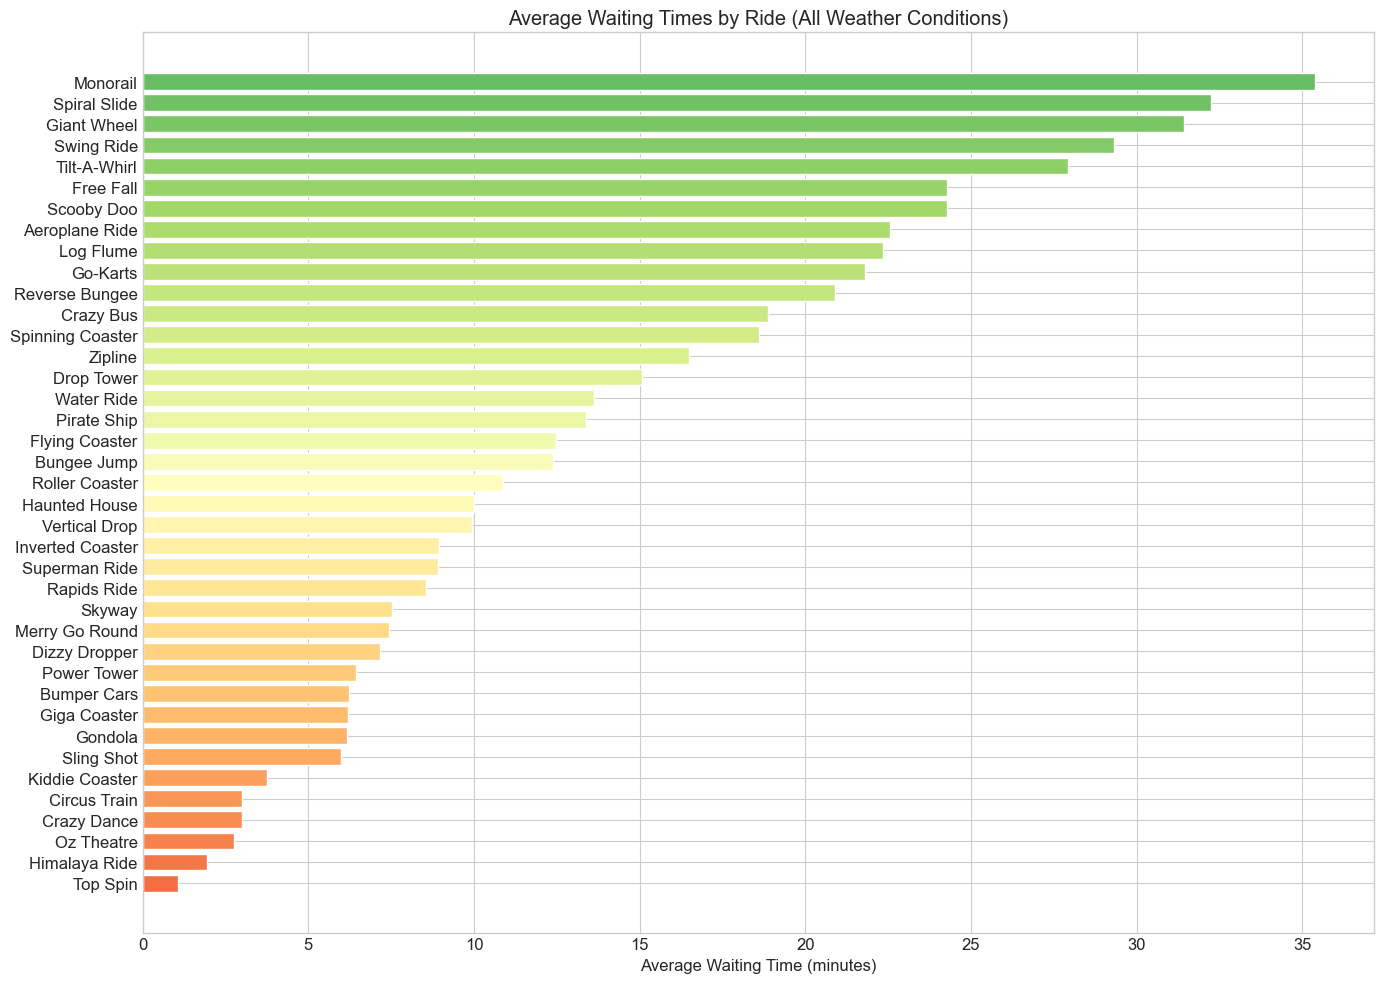

In [57]:
# ============================================================
# 5. OVERALL RIDE STATISTICS
# ============================================================
print("\n" + "="*70)
print("5. OVERALL RIDE STATISTICS")
print("="*70)

ride_stats = ride_weather.groupby('ride').agg({
    'wait_mean': ['mean', 'median', 'std'],
    'n_obs': 'sum',
    'guests': 'sum'
}).round(2)
ride_stats.columns = ['avg_wait', 'median_wait', 'std_wait', 'total_observations', 'total_guests']
ride_stats = ride_stats.sort_values('avg_wait', ascending=False)

print("\nRides by Average Waiting Time:")
print(ride_stats[['avg_wait', 'median_wait', 'std_wait']].to_string())

# Visualize
fig, ax = plt.subplots(figsize=(14, 10))
y_pos = np.arange(len(ride_stats))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ride_stats)))
ax.barh(y_pos, ride_stats['avg_wait'], color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(ride_stats.index)
ax.set_xlabel('Average Waiting Time (minutes)')
ax.set_title('Average Waiting Times by Ride (All Weather Conditions)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()



6. TEMPERATURE SENSITIVITY BY RIDE

Rides Most Positively Affected by Temperature (warmer = longer wait):
                  correlation       p_value       n  significant
Inverted Coaster     0.377452  2.181239e-58  1691.0         True
Superman Ride        0.356965  5.520186e-52  1691.0         True
Circus Train         0.318741  3.085389e-41  1691.0         True
Kiddie Coaster       0.310243  4.996485e-39  1690.0         True
Skyway               0.289482  5.302957e-34  1691.0         True
Dizzy Dropper        0.262797  4.154180e-28  1691.0         True
Vertical Drop        0.260178  2.843226e-02    71.0         True
Zipline              0.246041  1.009355e-24  1690.0         True
Rapids Ride          0.245391  1.306896e-24  1691.0         True
Pirate Ship          0.237629  3.892394e-23  1691.0         True

Rides Most Negatively Affected by Temperature (warmer = shorter wait):
                  correlation   p_value       n  significant
Free Fall            0.074059  0.002309  1691

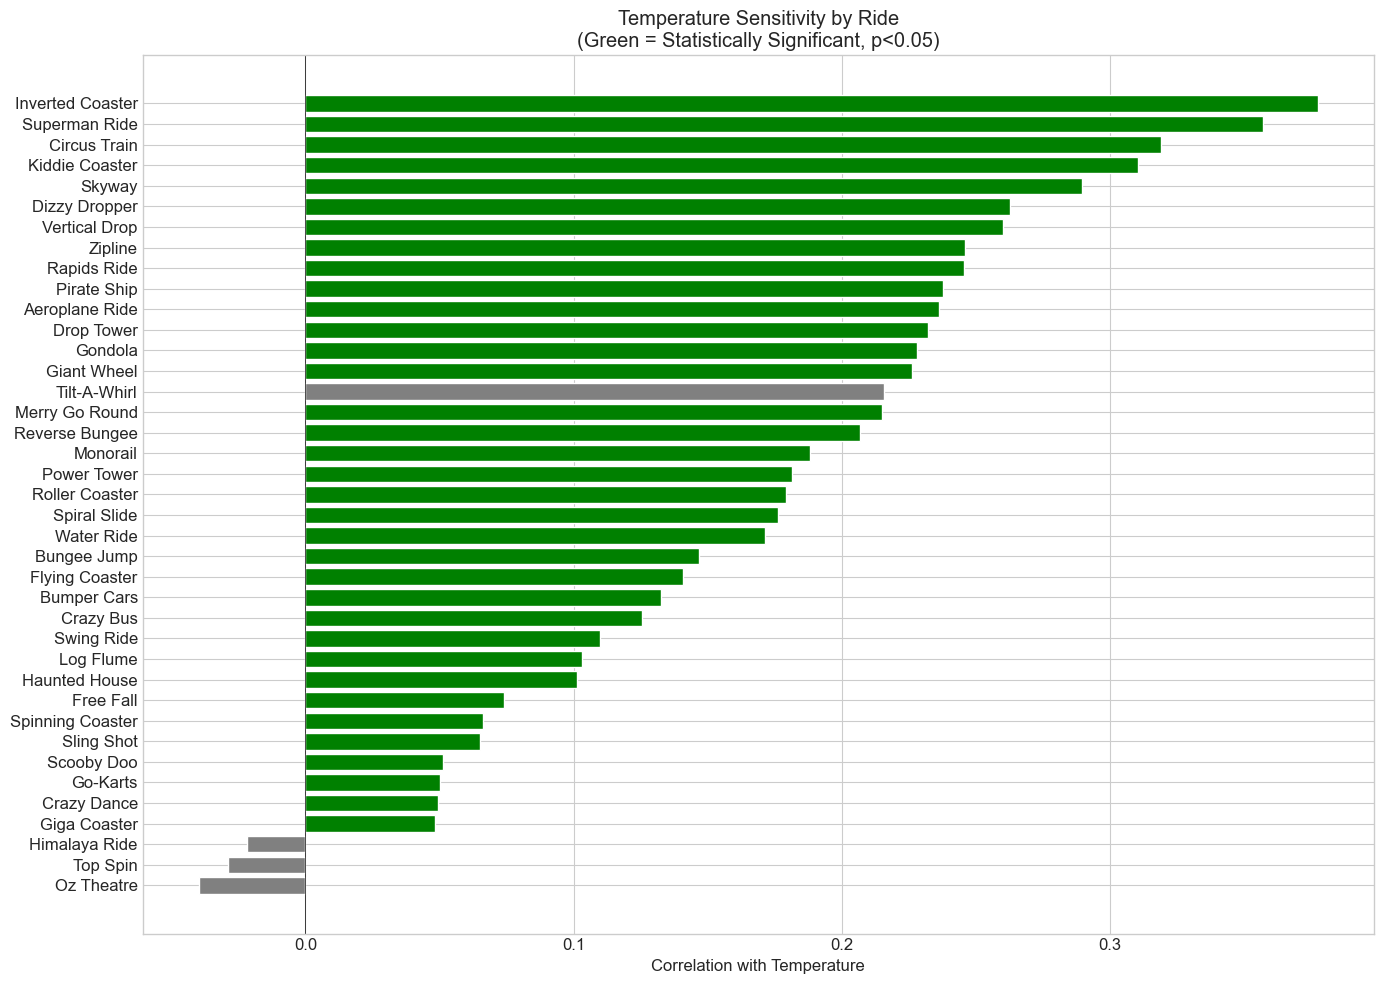

In [58]:
# ============================================================
# 6. CORRELATION WITH TEMPERATURE PER RIDE
# ============================================================
print("\n" + "="*70)
print("6. TEMPERATURE SENSITIVITY BY RIDE")
print("="*70)

temp_correlations = {}
for ride in ride_weather['ride'].unique():
    ride_data = ride_weather[ride_weather['ride'] == ride]
    if len(ride_data) >= 30:  # Require at least 30 observations
        corr, p_val = stats.pearsonr(ride_data['temp_mean'], ride_data['wait_mean'])
        temp_correlations[ride] = {'correlation': corr, 'p_value': p_val, 'n': len(ride_data)}

temp_corr_df = pd.DataFrame(temp_correlations).T.sort_values('correlation', ascending=False)
temp_corr_df['significant'] = temp_corr_df['p_value'] < 0.05

print("\nRides Most Positively Affected by Temperature (warmer = longer wait):")
print(temp_corr_df.head(10).to_string())

print("\nRides Most Negatively Affected by Temperature (warmer = shorter wait):")
print(temp_corr_df.tail(10).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['green' if x else 'gray' for x in temp_corr_df['significant']]
y_pos = np.arange(len(temp_corr_df))
ax.barh(y_pos, temp_corr_df['correlation'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(temp_corr_df.index)
ax.set_xlabel('Correlation with Temperature')
ax.set_title('Temperature Sensitivity by Ride\n(Green = Statistically Significant, p<0.05)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()



7. RAIN IMPACT BY RIDE

Rides with BIGGEST DECREASE in wait time when raining:
                no_rain_avg  rain_avg  difference  pct_change
Zipline               18.56     14.51       -4.04      -21.78
Monorail              37.23     33.63       -3.60       -9.66
Log Flume             23.73     21.02       -2.71      -11.42
Bungee Jump           13.72     11.11       -2.61      -19.04
Aeroplane Ride        23.69     21.48       -2.21       -9.31
Pirate Ship           14.47     12.35       -2.12      -14.63
Giant Wheel           32.45     30.45       -2.00       -6.16
Go-Karts              22.79     20.84       -1.95       -8.55
Reverse Bungee        21.87     19.95       -1.91       -8.74
Crazy Bus             19.69     18.11       -1.58       -8.01

Rides with BIGGEST INCREASE in wait time when raining:
                no_rain_avg  rain_avg  difference  pct_change
Sling Shot             5.99      5.99       -0.00       -0.02
Giga Coaster           6.21      6.22        0.01        0

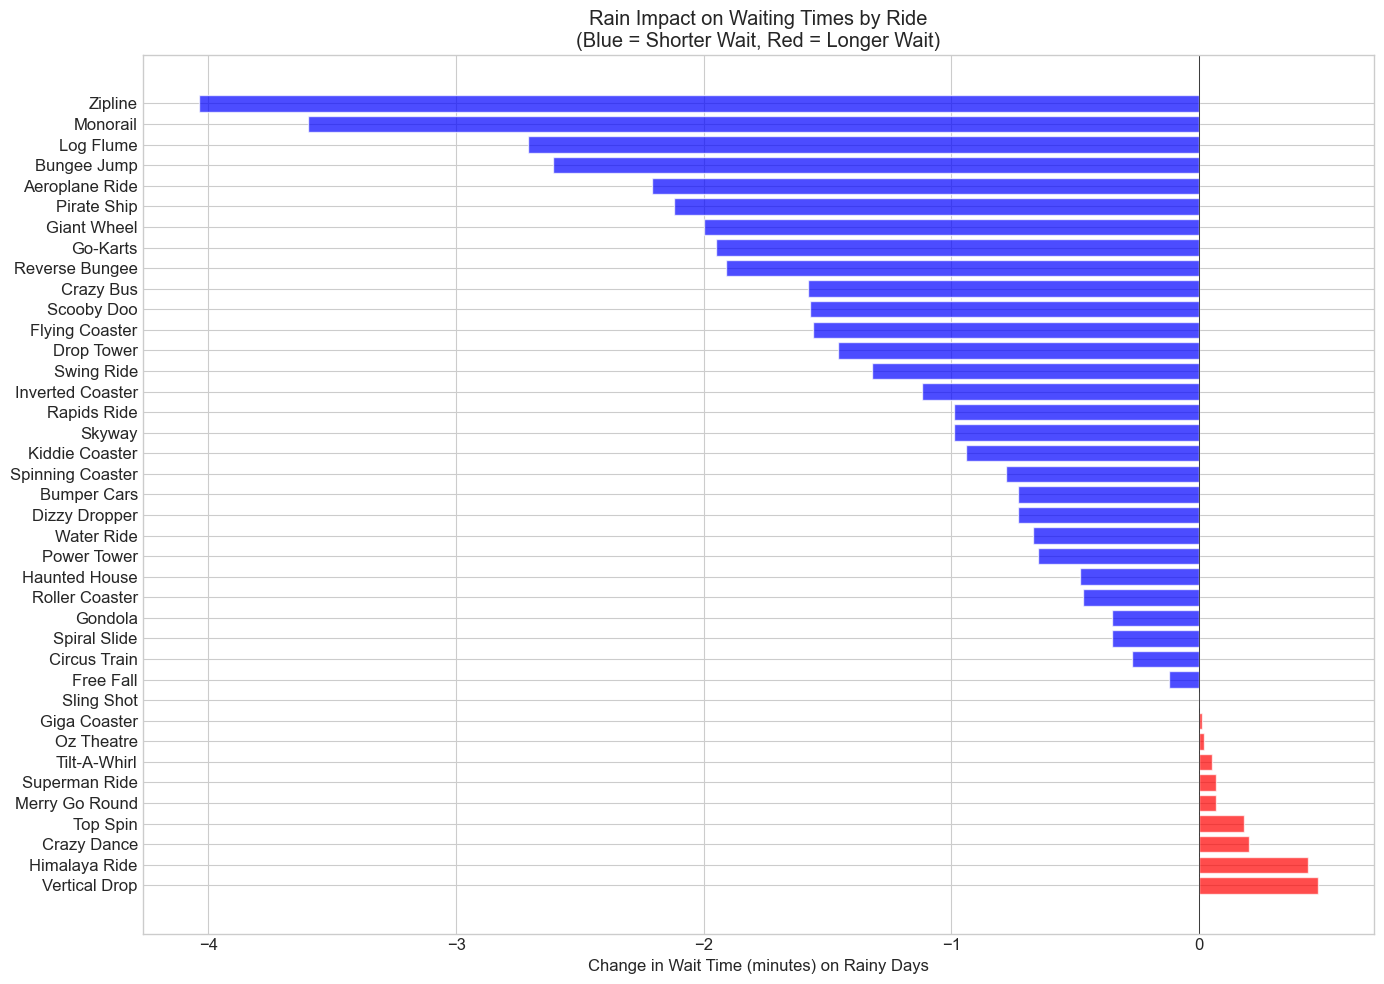

In [59]:
# ============================================================
# 7. RAIN IMPACT PER RIDE
# ============================================================
print("\n" + "="*70)
print("7. RAIN IMPACT BY RIDE")
print("="*70)

ride_weather['has_rain'] = ride_weather['rain_total'] > 0

rain_impact = {}
for ride in ride_weather['ride'].unique():
    ride_data = ride_weather[ride_weather['ride'] == ride]
    rain_days = ride_data[ride_data['has_rain']]['wait_mean']
    no_rain_days = ride_data[~ride_data['has_rain']]['wait_mean']
    
    if len(rain_days) >= 10 and len(no_rain_days) >= 10:
        diff = rain_days.mean() - no_rain_days.mean()
        pct_change = (diff / no_rain_days.mean()) * 100
        rain_impact[ride] = {
            'no_rain_avg': no_rain_days.mean(),
            'rain_avg': rain_days.mean(),
            'difference': diff,
            'pct_change': pct_change
        }

rain_df = pd.DataFrame(rain_impact).T.sort_values('difference')
rain_df = rain_df.round(2)

print("\nRides with BIGGEST DECREASE in wait time when raining:")
print(rain_df.head(10).to_string())

print("\nRides with BIGGEST INCREASE in wait time when raining:")
print(rain_df.tail(10).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(14, 10))
colors = ['blue' if x < 0 else 'red' for x in rain_df['difference']]
y_pos = np.arange(len(rain_df))
ax.barh(y_pos, rain_df['difference'], color=colors, edgecolor='white', alpha=0.7)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(rain_df.index)
ax.set_xlabel('Change in Wait Time (minutes) on Rainy Days')
ax.set_title('Rain Impact on Waiting Times by Ride\n(Blue = Shorter Wait, Red = Longer Wait)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()



8. WAITING TIMES BY WEATHER CONDITION (HEATMAP)


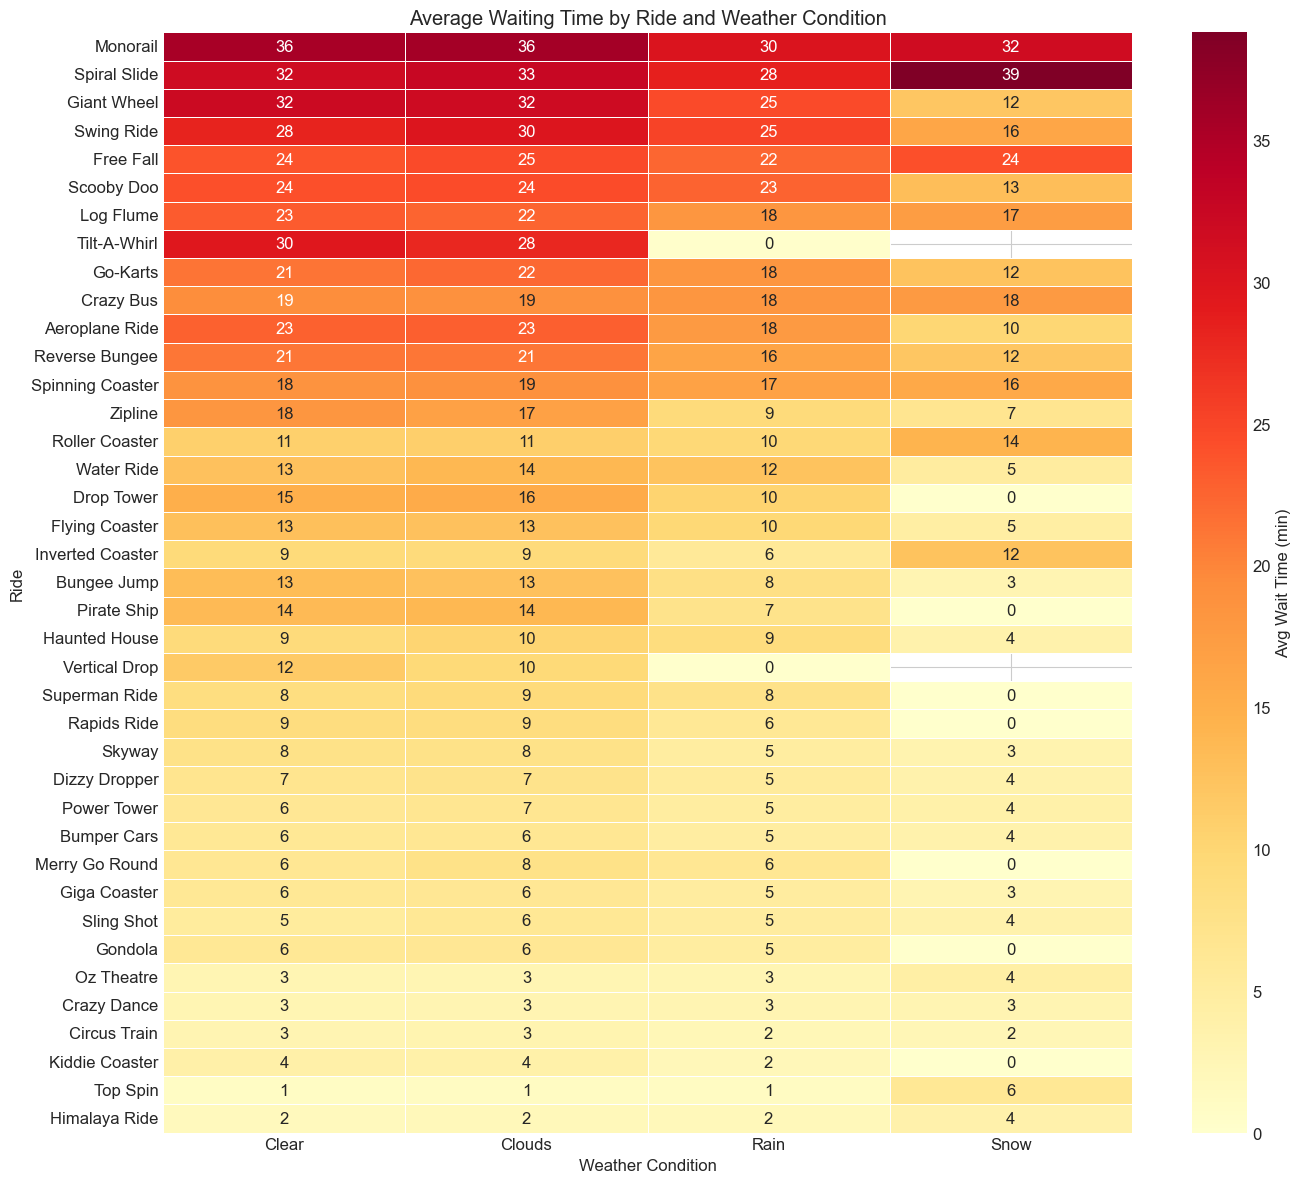

In [60]:

# ============================================================
# 8. WEATHER CONDITION IMPACT HEATMAP
# ============================================================
print("\n" + "="*70)
print("8. WAITING TIMES BY WEATHER CONDITION (HEATMAP)")
print("="*70)

# Create pivot table: rides x weather conditions
heatmap_data = ride_weather.pivot_table(
    values='wait_mean', 
    index='ride', 
    columns='weather_main', 
    aggfunc='mean'
).round(1)

# Keep only common weather conditions
common_weather = ['Clear', 'Clouds', 'Rain', 'Drizzle', 'Snow', 'Mist', 'Fog']
heatmap_data = heatmap_data[[c for c in common_weather if c in heatmap_data.columns]]

# Sort by overall average
heatmap_data['_avg'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('_avg', ascending=False)
heatmap_data = heatmap_data.drop('_avg', axis=1)

plt.figure(figsize=(14, 12))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', 
            linewidths=0.5, cbar_kws={'label': 'Avg Wait Time (min)'})
plt.xlabel('Weather Condition')
plt.ylabel('Ride')
plt.title('Average Waiting Time by Ride and Weather Condition')
plt.tight_layout()
plt.show()
plt.close()



9. WAITING TIMES BY TEMPERATURE CATEGORY (HEATMAP)


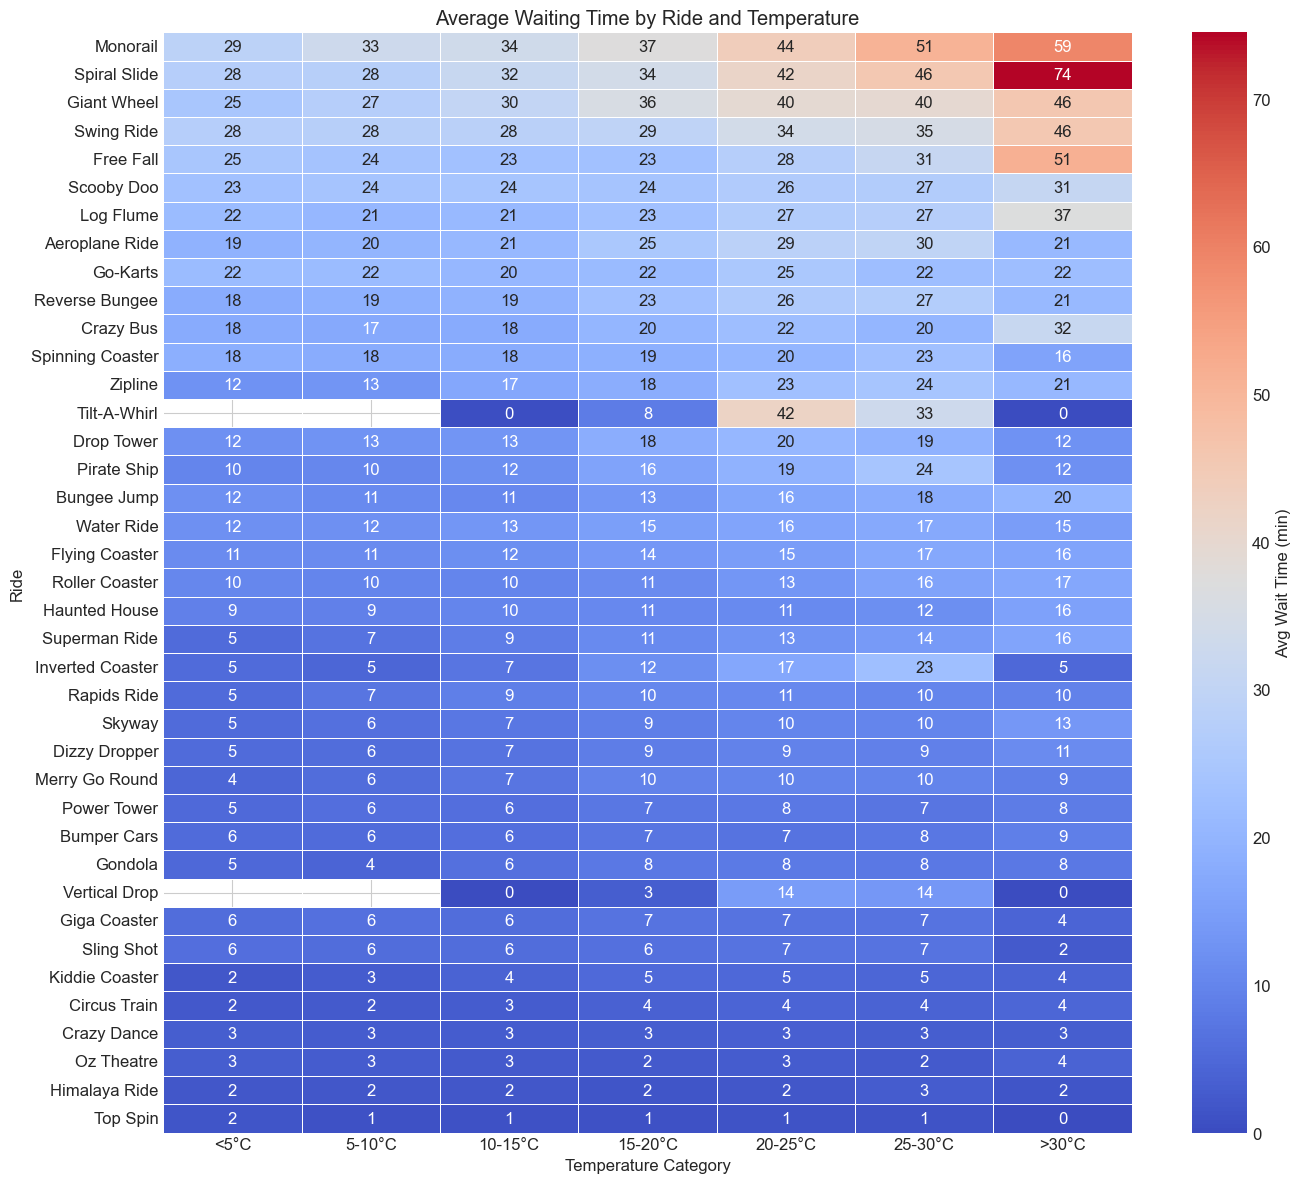

In [61]:
# ============================================================
# 9. TEMPERATURE CATEGORY IMPACT HEATMAP
# ============================================================
print("\n" + "="*70)
print("9. WAITING TIMES BY TEMPERATURE CATEGORY (HEATMAP)")
print("="*70)

temp_bins = [-10, 5, 10, 15, 20, 25, 30, 40]
temp_labels = ['<5°C', '5-10°C', '10-15°C', '15-20°C', '20-25°C', '25-30°C', '>30°C']
ride_weather['temp_cat'] = pd.cut(ride_weather['temp_mean'], bins=temp_bins, labels=temp_labels)

temp_heatmap = ride_weather.pivot_table(
    values='wait_mean', 
    index='ride', 
    columns='temp_cat', 
    aggfunc='mean'
).round(1)

# Sort by overall average
temp_heatmap['_avg'] = temp_heatmap.mean(axis=1)
temp_heatmap = temp_heatmap.sort_values('_avg', ascending=False)
temp_heatmap = temp_heatmap.drop('_avg', axis=1)

plt.figure(figsize=(14, 12))
sns.heatmap(temp_heatmap, cmap='coolwarm', annot=True, fmt='.0f', 
            linewidths=0.5, cbar_kws={'label': 'Avg Wait Time (min)'})
plt.xlabel('Temperature Category')
plt.ylabel('Ride')
plt.title('Average Waiting Time by Ride and Temperature')
plt.tight_layout()
plt.show()
plt.close()



10. OVERALL WEATHER SENSITIVITY RANKING

Rides MOST affected by weather (highest sensitivity):
                  cv_weather  temp_corr  rain_effect  mean_wait  sensitivity_score
Kiddie Coaster         74.36       0.31        22.26       3.74              92.82
Pirate Ship            74.88       0.24        14.63      13.39              86.15
Zipline                43.82       0.25        21.78      16.49              81.79
Rapids Ride            69.69       0.25        10.97       8.54              79.23
Skyway                 37.53       0.29        12.32       7.52              76.92
Vertical Drop          87.82       0.26         4.89       9.93              75.13
Drop Tower             70.33       0.23         9.21      15.06              74.10
Inverted Coaster       29.12       0.38        11.77       8.93              72.31
Bungee Jump            52.44       0.15        19.04      12.39              70.51
Top Spin              109.32       0.03        18.66       1.06           

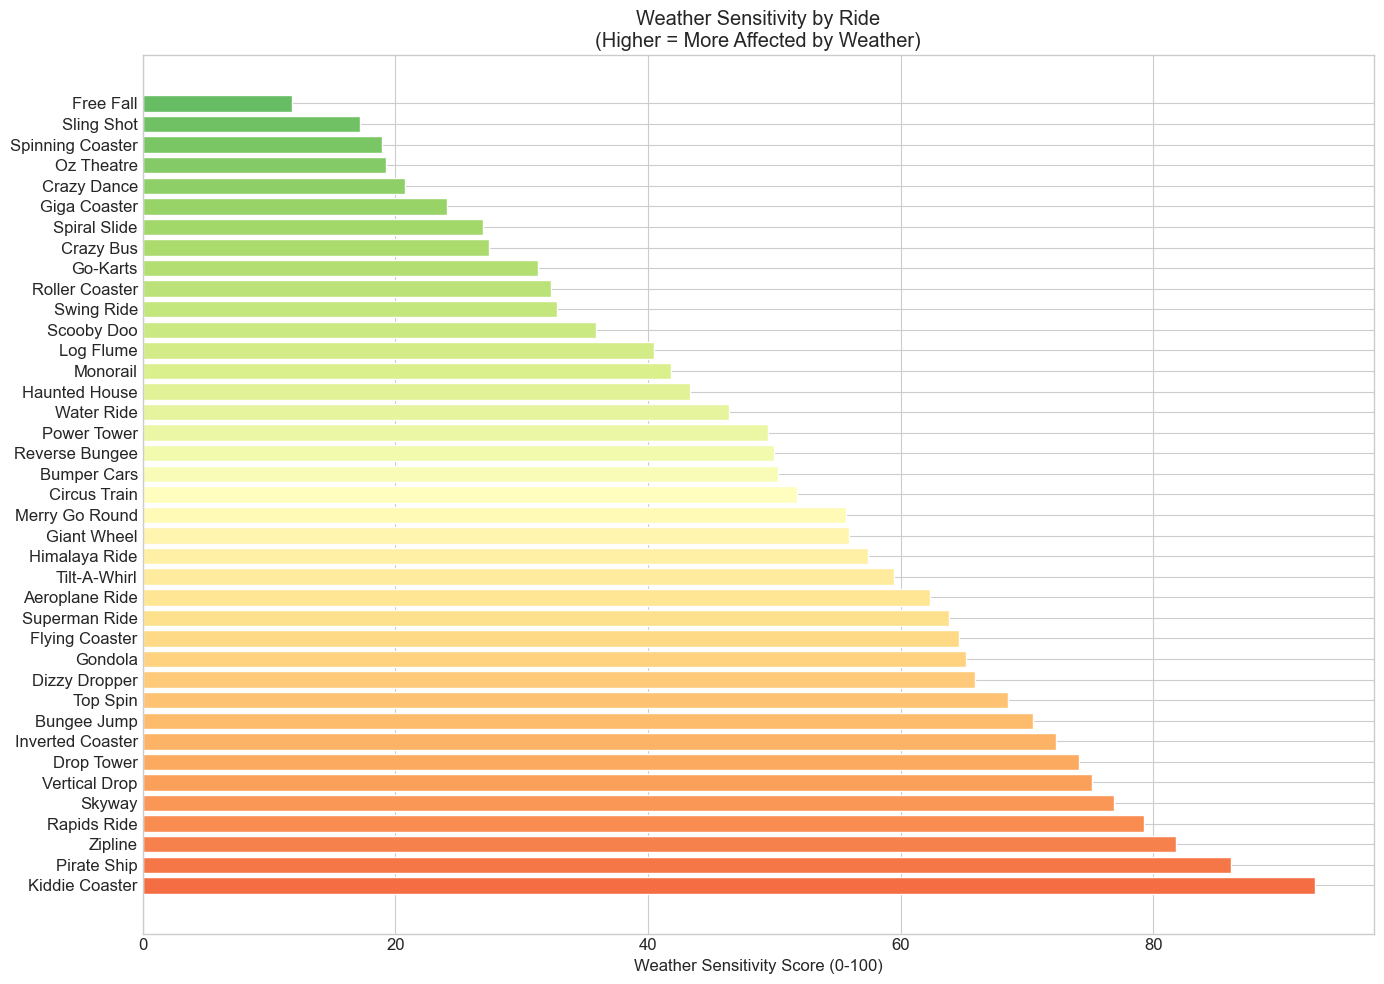

In [62]:
# ============================================================
# 10. WEATHER SENSITIVITY RANKING
# ============================================================
print("\n" + "="*70)
print("10. OVERALL WEATHER SENSITIVITY RANKING")
print("="*70)

# Calculate weather sensitivity score for each ride
# Higher score = more variation in wait times due to weather
weather_sensitivity = {}
for ride in ride_weather['ride'].unique():
    ride_data = ride_weather[ride_weather['ride'] == ride]
    if len(ride_data) >= 50:
        # Coefficient of variation of wait times across weather conditions
        by_weather = ride_data.groupby('weather_main')['wait_mean'].mean()
        if len(by_weather) >= 3:
            weather_sensitivity[ride] = {
                'cv_weather': by_weather.std() / by_weather.mean() * 100,
                'temp_corr': abs(temp_correlations.get(ride, {}).get('correlation', 0)),
                'rain_effect': abs(rain_impact.get(ride, {}).get('pct_change', 0)),
                'mean_wait': ride_data['wait_mean'].mean()
            }

sensitivity_df = pd.DataFrame(weather_sensitivity).T
sensitivity_df['sensitivity_score'] = (
    sensitivity_df['cv_weather'].rank(pct=True) * 0.4 +
    sensitivity_df['temp_corr'].rank(pct=True) * 0.3 +
    sensitivity_df['rain_effect'].rank(pct=True) * 0.3
) * 100

sensitivity_df = sensitivity_df.sort_values('sensitivity_score', ascending=False).round(2)

print("\nRides MOST affected by weather (highest sensitivity):")
print(sensitivity_df.head(10).to_string())

print("\nRides LEAST affected by weather (most stable):")
print(sensitivity_df.tail(10).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(14, 10))
sensitivity_sorted = sensitivity_df.sort_values('sensitivity_score')
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(sensitivity_sorted)))
y_pos = np.arange(len(sensitivity_sorted))
ax.barh(y_pos, sensitivity_sorted['sensitivity_score'], color=colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(sensitivity_sorted.index)
ax.set_xlabel('Weather Sensitivity Score (0-100)')
ax.set_title('Weather Sensitivity by Ride\n(Higher = More Affected by Weather)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
plt.close()



11. RIDE CATEGORIZATION


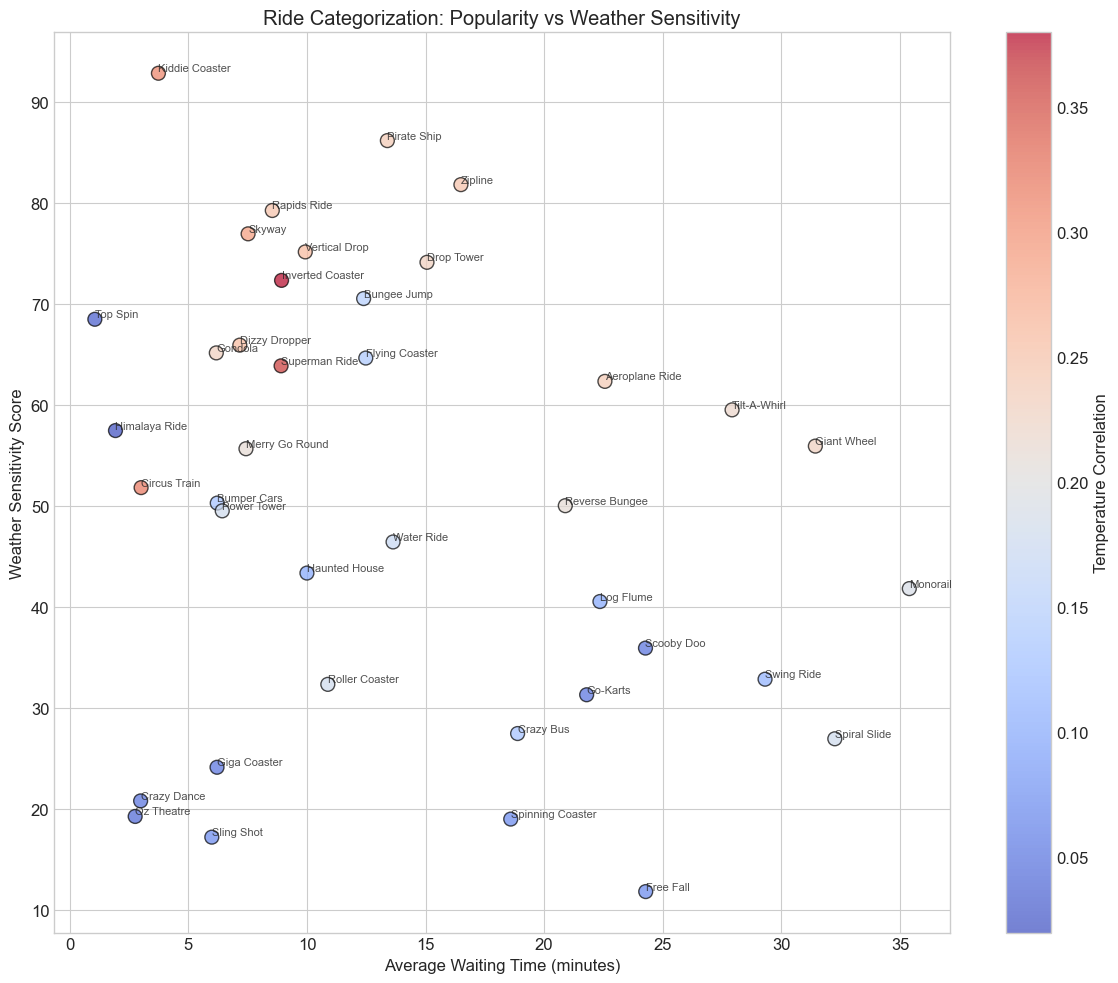

In [63]:
# ============================================================
# 11. SCATTER: POPULAR RIDES VS WEATHER SENSITIVE RIDES
# ============================================================
print("\n" + "="*70)
print("11. RIDE CATEGORIZATION")
print("="*70)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(sensitivity_df['mean_wait'], sensitivity_df['sensitivity_score'], 
                      s=100, c=sensitivity_df['temp_corr'], cmap='coolwarm', 
                      alpha=0.7, edgecolor='black')

# Add labels
for ride, row in sensitivity_df.iterrows():
    plt.annotate(ride, (row['mean_wait'], row['sensitivity_score']), 
                fontsize=8, alpha=0.8, ha='left', va='bottom')

plt.colorbar(scatter, label='Temperature Correlation')
plt.xlabel('Average Waiting Time (minutes)')
plt.ylabel('Weather Sensitivity Score')
plt.title('Ride Categorization: Popularity vs Weather Sensitivity')
plt.tight_layout()
plt.show()
plt.close()


In [64]:

# ============================================================
# 12. SUMMARY REPORT
# ============================================================
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)

print("\n📊 KEY FINDINGS:")

print("\n1. MOST POPULAR RIDES (Longest Wait Times):")
for i, (ride, row) in enumerate(ride_stats.head(5).iterrows(), 1):
    print(f"   {i}. {ride}: {row['avg_wait']:.1f} min avg wait")

print("\n2. MOST TEMPERATURE-SENSITIVE RIDES:")
for i, (ride, row) in enumerate(temp_corr_df[temp_corr_df['significant']].head(5).iterrows(), 1):
    print(f"   {i}. {ride}: r={row['correlation']:.3f}")

print("\n3. MOST RAIN-AFFECTED RIDES:")
most_rain_affected = rain_df.iloc[[0, -1]]  # Most decrease and most increase
print(f"   - Biggest DECREASE when raining: {rain_df.index[0]} ({rain_df.iloc[0]['difference']:.1f} min)")
print(f"   - Biggest INCREASE when raining: {rain_df.index[-1]} ({rain_df.iloc[-1]['difference']:.1f} min)")

print("\n4. OVERALL WEATHER SENSITIVITY:")
print(f"   - Most weather-sensitive: {sensitivity_df.index[0]} (score: {sensitivity_df.iloc[0]['sensitivity_score']:.1f})")
print(f"   - Most stable: {sensitivity_df.index[-1]} (score: {sensitivity_df.iloc[-1]['sensitivity_score']:.1f})")

print("\n" + "="*70)
print("ANALYSIS COMPLETE! Generated visualizations:")
print("="*70)
print("   1. ride_avg_waiting_times.png     - Average wait by ride")
print("   2. ride_temp_sensitivity.png      - Temperature correlation per ride")
print("   3. ride_rain_impact.png           - Rain impact per ride")
print("   4. ride_weather_heatmap.png       - Wait times by ride & weather")
print("   5. ride_temp_heatmap.png          - Wait times by ride & temperature")
print("   6. ride_weather_sensitivity.png   - Overall weather sensitivity")
print("   7. ride_categorization.png        - Popularity vs sensitivity scatter")

# Save summary data
sensitivity_df.to_csv('../final_data/ride_weather_sensitivity.csv')
print("\n   Saved: ../final_data/ride_weather_sensitivity.csv")


SUMMARY REPORT

📊 KEY FINDINGS:

1. MOST POPULAR RIDES (Longest Wait Times):
   1. Monorail: 35.4 min avg wait
   2. Spiral Slide: 32.2 min avg wait
   3. Giant Wheel: 31.4 min avg wait
   4. Swing Ride: 29.3 min avg wait
   5. Tilt-A-Whirl: 27.9 min avg wait

2. MOST TEMPERATURE-SENSITIVE RIDES:
   1. Inverted Coaster: r=0.377
   2. Superman Ride: r=0.357
   3. Circus Train: r=0.319
   4. Kiddie Coaster: r=0.310
   5. Skyway: r=0.289

3. MOST RAIN-AFFECTED RIDES:
   - Biggest DECREASE when raining: Zipline (-4.0 min)
   - Biggest INCREASE when raining: Vertical Drop (0.5 min)

4. OVERALL WEATHER SENSITIVITY:
   - Most weather-sensitive: Kiddie Coaster (score: 92.8)
   - Most stable: Free Fall (score: 11.8)

ANALYSIS COMPLETE! Generated visualizations:
   1. ride_avg_waiting_times.png     - Average wait by ride
   2. ride_temp_sensitivity.png      - Temperature correlation per ride
   3. ride_rain_impact.png           - Rain impact per ride
   4. ride_weather_heatmap.png       - Wait 